# Feedback run: Tables & Figures

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import os
from scipy import stats

matplotlib.rcParams.update({'font.size': 10, 'figure.dpi': 150})

RAW = '../results/raw_csv'
TABLES = '../results/tables'
FIGURES = '../results/figures'

master = pd.read_csv(f'{RAW}/master_analysis.csv')
tests = pd.read_csv(f'{RAW}/tests_all.csv')
cppcheck_det = pd.read_csv(f'{RAW}/cppcheck_detailed.csv')
cppcheck_sum = pd.read_csv(f'{RAW}/cppcheck_summary.csv')
clang_sum = pd.read_csv(f'{RAW}/clang_tidy_summary.csv')
clang_det = pd.read_csv(f'{RAW}/clang_tidy_detailed.csv')
agg = pd.read_csv(f'{RAW}/agg_per_model_gen.csv')

print(f'master: {len(master)} rows')
print(f'tests_all: {len(tests)} rows')
print(f'cppcheck_detailed: {len(cppcheck_det)} rows')
print(f'clang_tidy_detailed: {len(clang_det)} rows')

master: 8918 rows
tests_all: 8918 rows
cppcheck_detailed: 8410 rows
clang_tidy_detailed: 56311 rows


---
## Q2: Compilation & Runtime Success Rates per Model/Generation

> "How do you handle compilation failures and runtime errors in TPR computation? Are compile failures counted as zero pass rate, or excluded? Please report compile/run success rates per model/generation."

In [2]:
# Pipeline attrition table: total generated → compiled → had tests → passed ≥1 → all passed
q2 = tests.groupby(['model', 'generation']).agg(
    total_generated=('sample_id', 'count'),
    compiled=('compiled', 'sum'),
    had_tests=('has_tests', 'sum'),
    timed_out=('timeout', 'sum'),
).reset_index()

# Compute rates
q2['compile_rate'] = (q2['compiled'] / q2['total_generated']).round(3)

# For TPR: only programs with has_tests=1 are included; compile failures with has_tests=0 are excluded
# Programs that compiled but have no tests get pass_rate=NaN (excluded from TPR)
# Programs that failed to compile get compiled=0, pass_rate=NaN (excluded)
tpr_data = tests[tests['has_tests'] == 1].copy()
tpr_stats = tpr_data.groupby(['model', 'generation']).agg(
    n_with_tests=('sample_id', 'count'),
    mean_tpr=('pass_rate', 'mean'),
    all_pass=('pass_rate', lambda x: (x == 1.0).sum()),
    zero_pass=('pass_rate', lambda x: (x == 0.0).sum()),
).reset_index()

q2_full = q2.merge(tpr_stats, on=['model', 'generation'])
q2_full['test_coverage'] = (q2_full['had_tests'] / q2_full['total_generated']).round(3)
q2_full['timeout_rate'] = (q2_full['timed_out'] / q2_full['n_with_tests']).round(3)
q2_full['mean_tpr'] = q2_full['mean_tpr'].round(3)

cols = ['model', 'generation', 'total_generated', 'compiled', 'compile_rate',
        'had_tests', 'test_coverage', 'n_with_tests', 'mean_tpr',
        'all_pass', 'zero_pass', 'timed_out', 'timeout_rate']
q2_display = q2_full[cols].copy()
q2_display.columns = ['Model', 'Generation', 'Total Generated', 'Compiled', 'Compile Rate',
                       'Had Tests', 'Test Coverage', 'N (TPR calc)', 'Mean TPR',
                       'All Pass', 'Zero Pass', 'Timed Out', 'Timeout Rate']

q2_display.to_csv(f'{TABLES}/q2_pipeline_attrition.csv', index=False)
print('Table Q2: Pipeline Attrition per Model/Generation')
q2_display

Table Q2: Pipeline Attrition per Model/Generation


,Model,Generation,Total Generated,Compiled,Compile Rate,Had Tests,Test Coverage,N (TPR calc),Mean TPR,All Pass,Zero Pass,Timed Out,Timeout Rate
0,gemma,gen_1,745,668,0.897,402,0.540,402,0.465,89,69,56,0.139
1,gemma,gen_2,740,667,0.901,400,0.541,400,0.459,84,70,55,0.138
2,gemma,gen_3,753,683,0.907,404,0.537,404,0.479,96,71,51,0.126
3,human,soln1,851,831,0.976,494,0.580,494,0.832,370,42,5,0.010
4,human,soln2,844,834,0.988,500,0.592,500,0.828,378,44,4,0.008
5,llama,gen_1,849,763,0.899,468,0.551,468,0.423,94,107,50,0.107
6,llama,gen_2,800,736,0.920,438,0.548,438,0.426,92,96,49,0.112
7,llama,gen_3,847,773,0.913,476,0.562,476,0.426,103,115,52,0.109
8,qwen,gen_1,850,788,0.927,479,0.564,479,0.361,64,114,52,0.109
9,qwen,gen_2,823,745,0.905,451,0.548,451,0.382,71,113,53,0.118


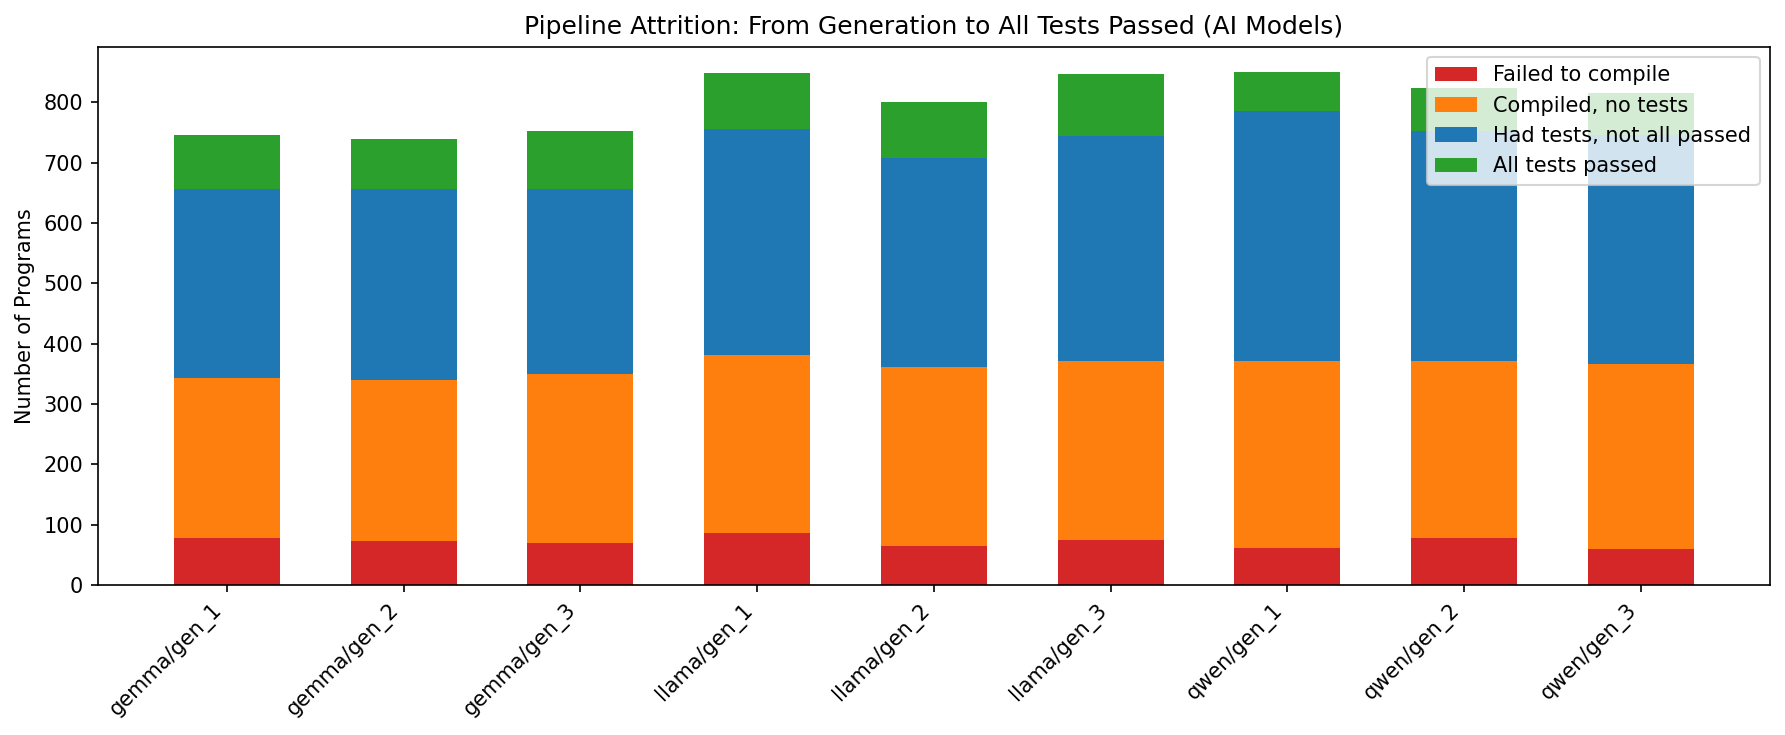

In [3]:
# Figure Q2: Stacked bar chart of pipeline attrition
fig, ax = plt.subplots(figsize=(12, 5))

ai_only = q2_full[~q2_full['model'].isin(['human'])].copy()
ai_only['label'] = ai_only['model'] + '/' + ai_only['generation']
ai_only = ai_only.sort_values(['model', 'generation'])

x = range(len(ai_only))
w = 0.6

not_compiled = ai_only['total_generated'] - ai_only['compiled']
compiled_no_tests = ai_only['compiled'] - ai_only['had_tests']
had_tests_not_pass = ai_only['n_with_tests'] - ai_only['all_pass']
all_passed = ai_only['all_pass']

ax.bar(x, not_compiled.values, w, label='Failed to compile', color='#d62728')
ax.bar(x, compiled_no_tests.values, w, bottom=not_compiled.values, label='Compiled, no tests', color='#ff7f0e')
ax.bar(x, had_tests_not_pass.values, w, bottom=(not_compiled + compiled_no_tests).values, label='Had tests, not all passed', color='#1f77b4')
ax.bar(x, all_passed.values, w, bottom=(not_compiled + compiled_no_tests + had_tests_not_pass).values, label='All tests passed', color='#2ca02c')

ax.set_xticks(x)
ax.set_xticklabels(ai_only['label'].values, rotation=45, ha='right')
ax.set_ylabel('Number of Programs')
ax.set_title('Pipeline Attrition: From Generation to All Tests Passed (AI Models)')
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig(f'{FIGURES}/q2_pipeline_attrition.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES}/q2_pipeline_attrition.png', bbox_inches='tight')
plt.show()

---
## Q4: Extraction Exclusion Rates (Fenced Code Blocks)

> "What fraction of generations lacked fenced C++ code blocks and were therefore excluded? Could this exclusion bias both TPR and static analysis prevalence?"

In [4]:
# 851 total instructions. Per model/gen, count how many were actually generated
# The difference (851 - generated) = failed API calls or responses without valid code

total_instructions = 851

q4_data = []
for _, row in agg.iterrows():
    generated = row['total_files']
    excluded = total_instructions - generated
    q4_data.append({
        'Model': row['model'],
        'Generation': row['gen'],
        'Total Instructions': total_instructions,
        'Extracted Programs': int(generated),
        'Excluded (no code / API fail)': int(excluded),
        'Exclusion Rate': round(excluded / total_instructions, 3),
        'Compiled': int(row['compiled_count']),
        'Compile Rate (of extracted)': round(row['compile_rate'], 3)
    })

q4_df = pd.DataFrame(q4_data)
q4_df.to_csv(f'{TABLES}/q4_extraction_exclusion.csv', index=False)
print('Table Q4: Extraction and Exclusion Rates')
q4_df

Table Q4: Extraction and Exclusion Rates


,Model,Generation,Total Instructions,Extracted Programs,Excluded (no code / API fail),Exclusion Rate,Compiled,Compile Rate (of extracted)
0,gemma,gen_1,851,745,106,0.125,668,0.897
1,gemma,gen_2,851,740,111,0.130,667,0.901
2,gemma,gen_3,851,753,98,0.115,683,0.907
3,human,soln1,851,851,0,0.000,831,0.976
4,human,soln2,851,844,7,0.008,834,0.988
5,llama,gen_1,851,849,2,0.002,763,0.899
6,llama,gen_2,851,800,51,0.060,736,0.920
7,llama,gen_3,851,847,4,0.005,773,0.913
8,qwen,gen_1,851,850,1,0.001,788,0.927
9,qwen,gen_2,851,823,28,0.033,745,0.905


---
## Q5: Per-CWE Distributions (Top 10 by Frequency) with Severity

> "For RQ1, can you provide per-CWE distributions (top 10 by frequency) and severity aggregation, rather than only 'any CWE' prevalence?"

In [5]:
# MITRE CWE severity mapping (based on MITRE Top-25 2024 and CVSS typical scores)
cwe_severity = {
    'CWE-119': ('Buffer Overflow', 'High', True),
    'CWE-190': ('Integer Overflow', 'High', True),
    'CWE-197': ('Numeric Truncation', 'Medium', False),
    'CWE-252': ('Unchecked Return Value', 'Medium', False),
    'CWE-369': ('Divide By Zero', 'Medium', False),
    'CWE-391': ('Unchecked Error Condition', 'Low', False),
    'CWE-398': ('Code Quality (Variable Scope)', 'Low', False),
    'CWE-457': ('Use of Uninitialized Variable', 'High', True),
    'CWE-476': ('NULL Pointer Dereference', 'High', True),
    'CWE-477': ('Obsolete Function', 'Low', False),
    'CWE-561': ('Dead Code', 'Low', False),
    'CWE-562': ('Return of Stack Variable Address', 'High', False),
    'CWE-563': ('Unused Variable Assignment', 'Low', False),
    'CWE-570': ('Expression Always False', 'Medium', False),
    'CWE-571': ('Expression Always True', 'Medium', False),
    'CWE-628': ('Function Call Wrong Args', 'Medium', False),
    'CWE-664': ('Improper Resource Control', 'Medium', False),
    'CWE-665': ('Improper Initialization', 'Medium', False),
    'CWE-686': ('Function Call Wrong Arg Type', 'Medium', False),
    'CWE-704': ('Incorrect Type Conversion', 'Medium', False),
    'CWE-758': ('Undefined Behavior', 'High', False),
    'CWE-762': ('Mismatched Memory Routines', 'High', False),
    'CWE-772': ('Missing Resource Release', 'Medium', False),
    'CWE-783': ('Operator Precedence Error', 'Medium', False),
    'CWE-786': ('Buffer Under-read', 'High', True),
    'CWE-788': ('Buffer Over-read', 'High', True),
    'CWE-825': ('Expired Pointer Dereference', 'High', False),
}

# Build per-CWE table with total findings across all models
cwe_prev = pd.read_csv(f'{RAW}/cwe_prevalence.csv')

# Aggregate findings per CWE across AI models only
ai_cwes = cwe_prev[cwe_prev['model'] != 'human'].groupby('cwe').agg(
    ai_total_findings=('total_findings', 'sum'),
    ai_files_affected=('files_affected', 'sum')
).reset_index()

human_cwes = cwe_prev[cwe_prev['model'] == 'human'].groupby('cwe').agg(
    human_total_findings=('total_findings', 'sum'),
    human_files_affected=('files_affected', 'sum')
).reset_index()

q5 = ai_cwes.merge(human_cwes, on='cwe', how='outer').fillna(0)

# Add severity info
q5['Description'] = q5['cwe'].map(lambda x: cwe_severity.get(x, ('Unknown', 'Unknown', False))[0])
q5['Severity'] = q5['cwe'].map(lambda x: cwe_severity.get(x, ('Unknown', 'Unknown', False))[1])
q5['MITRE Top-25'] = q5['cwe'].map(lambda x: cwe_severity.get(x, ('Unknown', 'Unknown', False))[2])

q5 = q5.sort_values('ai_total_findings', ascending=False)
q5_top10 = q5.head(10).copy()
q5_top10.columns = ['CWE', 'AI Total Findings', 'AI Files Affected',
                     'Human Total Findings', 'Human Files Affected',
                     'Description', 'Severity', 'MITRE Top-25']

q5_top10 = q5_top10[['CWE', 'Description', 'Severity', 'MITRE Top-25',
                      'AI Total Findings', 'AI Files Affected',
                      'Human Total Findings', 'Human Files Affected']]
q5_top10['AI Total Findings'] = q5_top10['AI Total Findings'].astype(int)
q5_top10['AI Files Affected'] = q5_top10['AI Files Affected'].astype(int)
q5_top10['Human Total Findings'] = q5_top10['Human Total Findings'].astype(int)
q5_top10['Human Files Affected'] = q5_top10['Human Files Affected'].astype(int)

q5_top10.to_csv(f'{TABLES}/q5_top10_cwe_with_severity.csv', index=False)
print('Table Q5: Top 10 CWEs by Frequency with Severity')
q5_top10

Table Q5: Top 10 CWEs by Frequency with Severity


,CWE,Description,Severity,MITRE Top-25,AI Total Findings,AI Files Affected,Human Total Findings,Human Files Affected
6,CWE-398,Code Quality (Variable Scope),Low,False,3736,2200,1410,548
12,CWE-563,Unused Variable Assignment,Low,False,1708,707,548,193
14,CWE-571,Expression Always True,Medium,False,137,95,31,22
13,CWE-570,Expression Always False,Medium,False,123,76,9,9
7,CWE-457,Use of Uninitialized Variable,High,True,73,36,71,38
24,CWE-786,Buffer Under-read,High,True,68,44,12,10
20,CWE-758,Undefined Behavior,High,False,23,20,23,17
2,CWE-197,Numeric Truncation,Medium,False,20,15,6,6
25,CWE-788,Buffer Over-read,High,True,18,11,22,18
16,CWE-664,Improper Resource Control,Medium,False,17,10,0,0


In [6]:
# Per-model breakdown of top-10 CWEs
top10_cwes = q5_top10['CWE'].tolist()
cwe_by_model = cwe_prev[cwe_prev['cwe'].isin(top10_cwes)].copy()

# Pivot: rows=CWE, columns=model, values=total_findings
q5_pivot = cwe_by_model.pivot_table(
    index='cwe', columns='model', values='total_findings', fill_value=0
).astype(int)

# Add description/severity
q5_pivot['Description'] = q5_pivot.index.map(lambda x: cwe_severity.get(x, ('?','?',False))[0])
q5_pivot['Severity'] = q5_pivot.index.map(lambda x: cwe_severity.get(x, ('?','?',False))[1])

q5_pivot = q5_pivot[['Description', 'Severity', 'gemma', 'llama', 'qwen', 'human']]
q5_pivot = q5_pivot.sort_values('gemma', ascending=False)

q5_pivot.to_csv(f'{TABLES}/q5_cwe_by_model_with_severity.csv')
print('Table Q5b: CWE Findings by Model with Severity')
q5_pivot

Table Q5b: CWE Findings by Model with Severity


model,Description,Severity,gemma,llama,qwen,human
cwe,,,,,,
CWE-398,Code Quality (Variable Scope),Low,1360,1111,1265,1410
CWE-563,Unused Variable Assignment,Low,884,377,447,548
CWE-571,Expression Always True,Medium,77,32,28,31
CWE-570,Expression Always False,Medium,67,13,43,9
CWE-786,Buffer Under-read,High,25,28,15,12
CWE-457,Use of Uninitialized Variable,High,17,31,25,71
CWE-758,Undefined Behavior,High,8,6,9,23
CWE-197,Numeric Truncation,Medium,4,8,8,6
CWE-664,Improper Resource Control,Medium,0,10,7,0


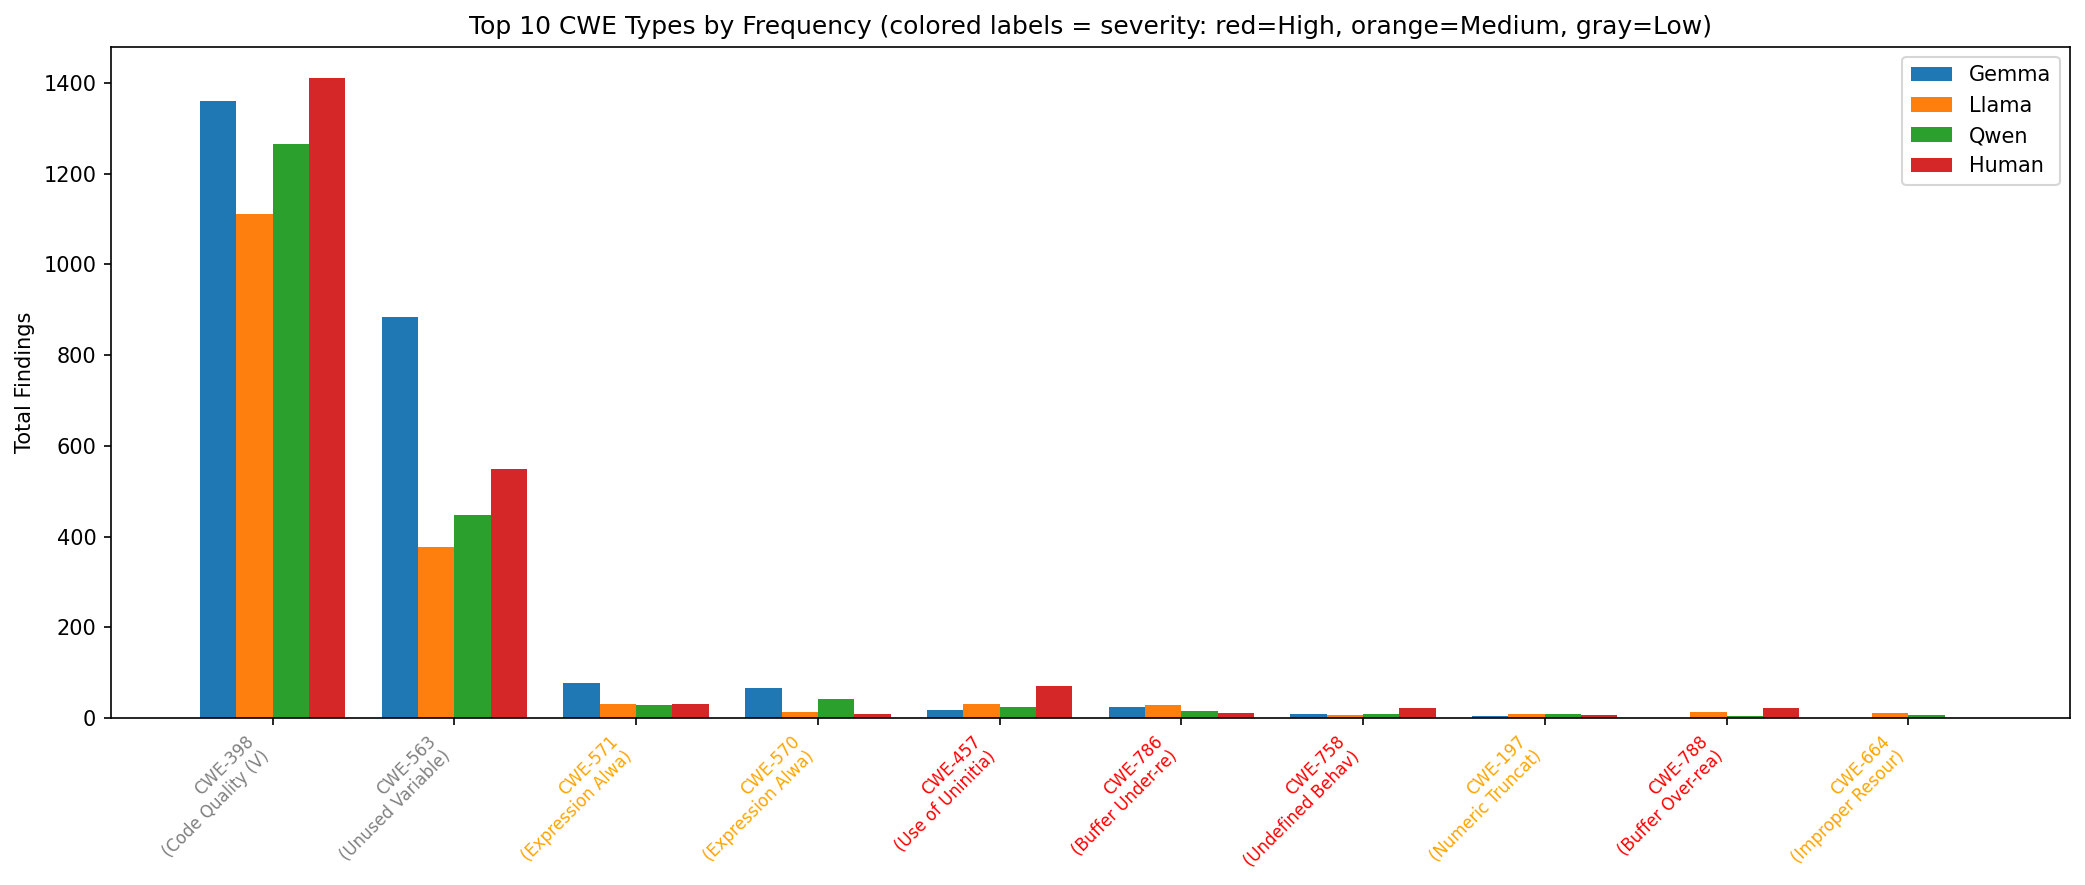

In [7]:
# Figure Q5: Grouped bar chart of top-10 CWEs by model
fig, ax = plt.subplots(figsize=(14, 6))

models = ['gemma', 'llama', 'qwen', 'human']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
x = np.arange(len(top10_cwes))
width = 0.2

for i, (model, color) in enumerate(zip(models, colors)):
    vals = []
    for cwe in top10_cwes:
        row = cwe_by_model[(cwe_by_model['cwe'] == cwe) & (cwe_by_model['model'] == model)]
        vals.append(row['total_findings'].values[0] if len(row) > 0 else 0)
    ax.bar(x + i * width, vals, width, label=model.capitalize(), color=color)

# Color x-tick labels by severity
sev_colors = {'High': 'red', 'Medium': 'orange', 'Low': 'gray'}
labels = [f"{c}\n({cwe_severity.get(c, ('?','?',False))[0][:15]})" for c in top10_cwes]

ax.set_xticks(x + 1.5 * width)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)

# Color labels by severity
for i, cwe in enumerate(top10_cwes):
    sev = cwe_severity.get(cwe, ('?','?',False))[1]
    ax.get_xticklabels()[i].set_color(sev_colors.get(sev, 'black'))

ax.set_ylabel('Total Findings')
ax.set_title('Top 10 CWE Types by Frequency (colored labels = severity: red=High, orange=Medium, gray=Low)')
ax.legend()
plt.tight_layout()
plt.savefig(f'{FIGURES}/q5_top10_cwe_by_model_severity.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES}/q5_top10_cwe_by_model_severity.png', bbox_inches='tight')
plt.show()

In [8]:
# Severity aggregation table
all_cwes_with_sev = q5.copy()
sev_agg = all_cwes_with_sev.groupby('Severity').agg(
    n_cwe_types=('cwe', 'count'),
    ai_total=('ai_total_findings', 'sum'),
    ai_files=('ai_files_affected', 'sum'),
    human_total=('human_total_findings', 'sum'),
    human_files=('human_files_affected', 'sum')
).reset_index()

sev_agg.columns = ['Severity', '# CWE Types', 'AI Total Findings', 'AI Files',
                    'Human Total Findings', 'Human Files']
sev_agg = sev_agg.sort_values('AI Total Findings', ascending=False)
sev_agg.to_csv(f'{TABLES}/q5_severity_aggregation.csv', index=False)
print('Table Q5c: Severity Aggregation')
sev_agg

Table Q5c: Severity Aggregation


,Severity,# CWE Types,AI Total Findings,AI Files,Human Total Findings,Human Files
1,Low,5,5450,2909,1971,751
2,Medium,12,315,211,119,89
0,High,10,212,130,239,175


---
## Q8: Per-Problem Paired Comparisons (LLM vs Human)

> "How were human solutions selected and normalized? Can you provide per-problem paired comparisons (LLM vs. human) on warning counts and categories?"

In [9]:
# Per-problem paired comparison: for each problem, average the human warning counts
# and the AI warning counts, then compare

# Human solutions
human_df = master[master['model'] == 'human'].copy()
human_agg = human_df.groupby('problem_key').agg(
    human_cppcheck_total=('cppcheck_total', 'mean'),
    human_cppcheck_cwe=('cppcheck_cwe_count', 'mean'),
    human_clang_total=('clang_total', 'mean'),
    human_clang_bugprone=('clang_bugprone', 'mean'),
    human_clang_analyzer=('clang_analyzer', 'mean'),
    human_pass_rate=('pass_rate', 'mean'),
    human_n=('sample_id', 'count')
).reset_index()

# AI solutions (average across all models and generations per problem)
ai_df = master[master['model'] != 'human'].copy()
ai_agg = ai_df.groupby('problem_key').agg(
    ai_cppcheck_total=('cppcheck_total', 'mean'),
    ai_cppcheck_cwe=('cppcheck_cwe_count', 'mean'),
    ai_clang_total=('clang_total', 'mean'),
    ai_clang_bugprone=('clang_bugprone', 'mean'),
    ai_clang_analyzer=('clang_analyzer', 'mean'),
    ai_pass_rate=('pass_rate', 'mean'),
    ai_n=('sample_id', 'count')
).reset_index()

# Also per-model
ai_per_model = ai_df.groupby(['model', 'problem_key']).agg(
    ai_cppcheck_total=('cppcheck_total', 'mean'),
    ai_cppcheck_cwe=('cppcheck_cwe_count', 'mean'),
    ai_clang_total=('clang_total', 'mean'),
    ai_clang_bugprone=('clang_bugprone', 'mean'),
    ai_clang_analyzer=('clang_analyzer', 'mean'),
    ai_pass_rate=('pass_rate', 'mean'),
).reset_index()

paired = human_agg.merge(ai_agg, on='problem_key', how='inner')
print(f'Paired problems (both human and AI): {len(paired)}')

# Summary statistics of the paired differences
metrics = [
    ('cppcheck_total', 'Cppcheck Total Warnings'),
    ('cppcheck_cwe', 'Cppcheck CWE Count'),
    ('clang_total', 'Clang-Tidy Total Diagnostics'),
    ('clang_bugprone', 'Clang-Tidy Bugprone'),
    ('clang_analyzer', 'Clang-Tidy Analyzer'),
]

paired_stats = []
for metric, label in metrics:
    h = paired[f'human_{metric}']
    a = paired[f'ai_{metric}']
    diff = h - a  # positive = human has more
    t_stat, p_val = stats.ttest_rel(h, a)
    paired_stats.append({
        'Metric': label,
        'Human Mean': round(h.mean(), 3),
        'AI Mean': round(a.mean(), 3),
        'Mean Diff (H-AI)': round(diff.mean(), 3),
        'Std Diff': round(diff.std(), 3),
        't-statistic': round(t_stat, 3),
        'p-value': f'{p_val:.2e}',
        'N problems': len(paired)
    })

q8_table = pd.DataFrame(paired_stats)
q8_table.to_csv(f'{TABLES}/q8_paired_comparison.csv', index=False)
print('Table Q8: Paired Per-Problem Comparison (Human vs AI)')
q8_table

Paired problems (both human and AI): 851
Table Q8: Paired Per-Problem Comparison (Human vs AI)


,Metric,Human Mean,AI Mean,Mean Diff (H-AI),Std Diff,t-statistic,p-value,N problems
0,Cppcheck Total Warnings,1.380,0.857,0.523,2.219,6.872,1.22e-11,851
1,Cppcheck CWE Count,0.599,0.457,0.142,0.628,6.583,8.08e-11,851
2,Clang-Tidy Total Diagnostics,10.197,5.483,4.715,10.025,13.718,7.76e-39,851
3,Clang-Tidy Bugprone,2.070,0.500,1.570,3.650,12.545,3.05e-33,851
4,Clang-Tidy Analyzer,0.468,0.107,0.361,0.766,13.749,5.52e-39,851


In [10]:
# Per-model paired comparison
paired_by_model = []
for model in ['gemma', 'llama', 'qwen']:
    model_ai = ai_per_model[ai_per_model['model'] == model]
    p = human_agg.merge(model_ai, on='problem_key', how='inner', suffixes=('', '_m'))
    for metric, label in metrics:
        h = p[f'human_{metric}']
        a = p[f'ai_{metric}']
        diff = h - a
        t_stat, p_val = stats.ttest_rel(h, a)
        paired_by_model.append({
            'Model': model.capitalize(),
            'Metric': label,
            'Human Mean': round(h.mean(), 3),
            f'{model.capitalize()} Mean': round(a.mean(), 3),
            'Mean Diff': round(diff.mean(), 3),
            'p-value': f'{p_val:.2e}',
            'N': len(p)
        })

q8b = pd.DataFrame(paired_by_model)
q8b.to_csv(f'{TABLES}/q8_paired_by_model.csv', index=False)
print('Table Q8b: Paired Comparison by Model')
q8b

Table Q8b: Paired Comparison by Model


,Model,Metric,Human Mean,Gemma Mean,Mean Diff,p-value,N,Llama Mean,Qwen Mean
0,Gemma,Cppcheck Total Warnings,1.371,1.185,0.186,4.49e-02,835,NaN,NaN
1,Gemma,Cppcheck CWE Count,0.593,0.586,0.007,8.16e-01,835,NaN,NaN
2,Gemma,Clang-Tidy Total Diagnostics,10.200,7.182,3.018,6.84e-14,835,NaN,NaN
3,Gemma,Clang-Tidy Bugprone,2.078,0.434,1.644,4.87e-33,835,NaN,NaN
4,Gemma,Clang-Tidy Analyzer,0.468,0.143,0.325,9.52e-24,835,NaN,NaN
5,Llama,Cppcheck Total Warnings,1.380,NaN,0.707,1.46e-19,851,0.673,NaN
6,Llama,Cppcheck CWE Count,0.599,NaN,0.213,3.43e-20,851,0.385,NaN
7,Llama,Clang-Tidy Total Diagnostics,10.197,NaN,5.196,5.98e-46,851,5.001,NaN
8,Llama,Clang-Tidy Bugprone,2.070,NaN,1.528,2.28e-31,851,0.542,NaN
9,Llama,Clang-Tidy Analyzer,0.468,NaN,0.370,2.53e-40,851,0.099,NaN


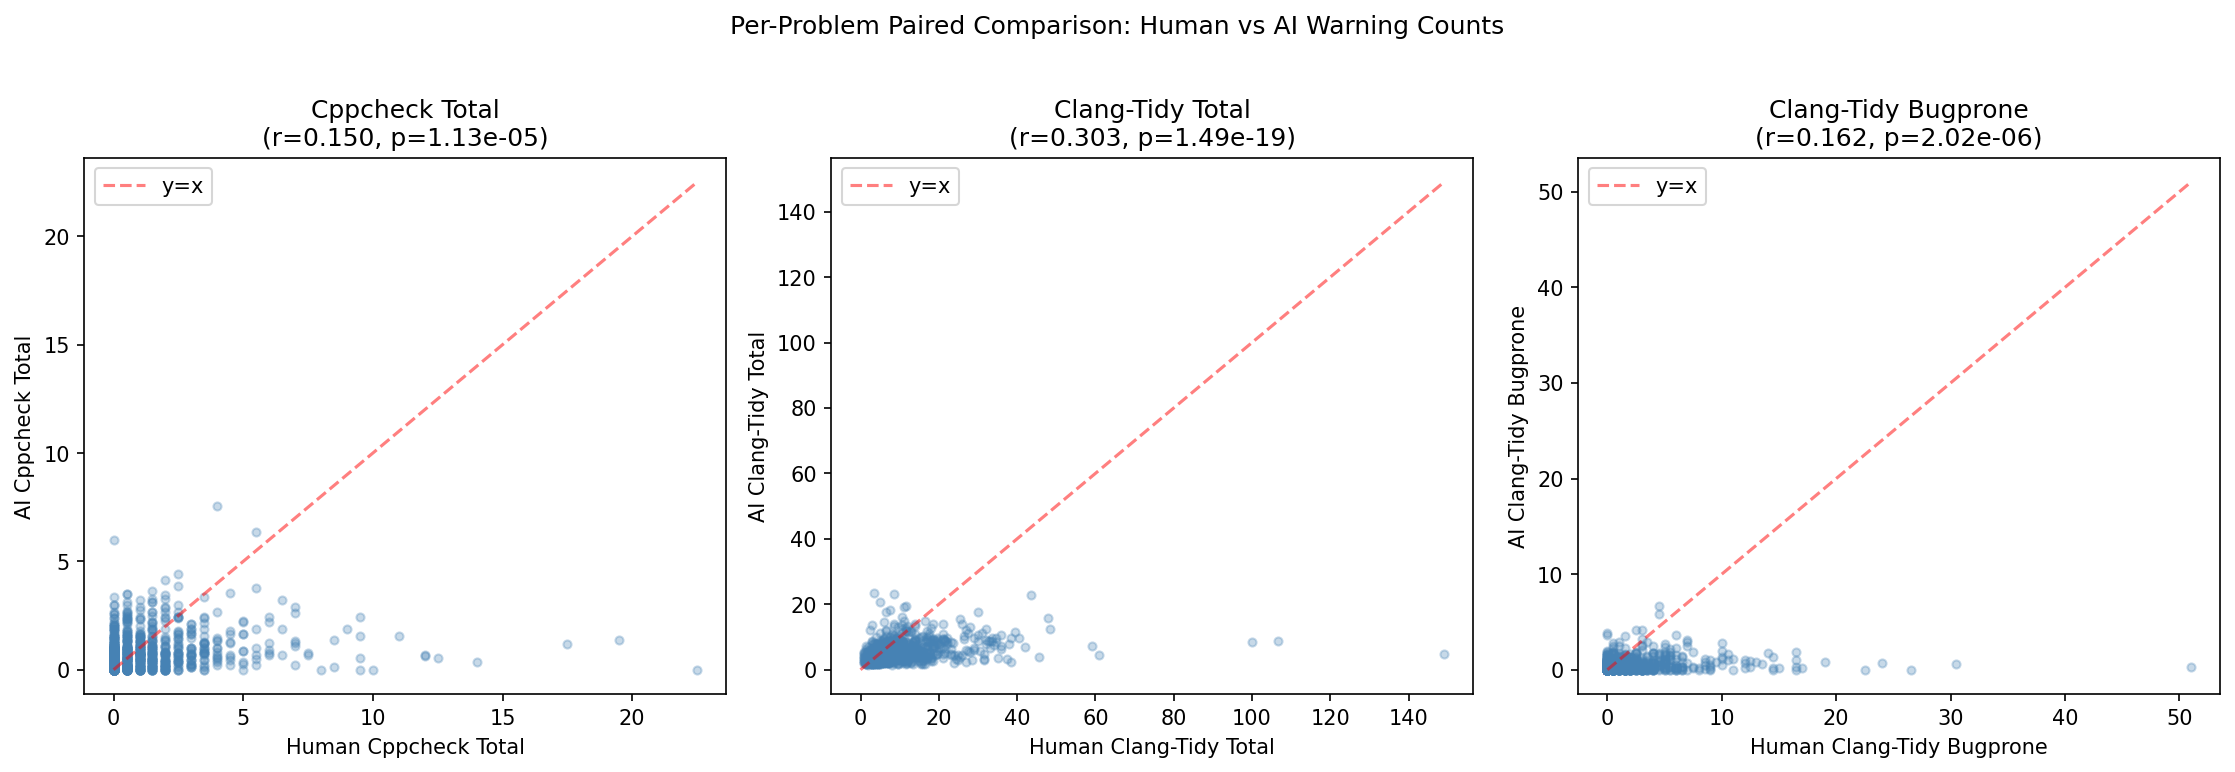

In [11]:
# Figure Q8: Scatter plot of per-problem warning counts (Human vs AI)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

scatter_metrics = [
    ('cppcheck_total', 'Cppcheck Total'),
    ('clang_total', 'Clang-Tidy Total'),
    ('clang_bugprone', 'Clang-Tidy Bugprone'),
]

for ax, (metric, label) in zip(axes, scatter_metrics):
    h = paired[f'human_{metric}']
    a = paired[f'ai_{metric}']
    ax.scatter(h, a, alpha=0.3, s=15, color='steelblue')
    max_val = max(h.max(), a.max())
    ax.plot([0, max_val], [0, max_val], 'r--', alpha=0.5, label='y=x')
    r, p = stats.pearsonr(h, a)
    ax.set_xlabel(f'Human {label}')
    ax.set_ylabel(f'AI {label}')
    ax.set_title(f'{label}\n(r={r:.3f}, p={p:.2e})')
    ax.legend()

plt.suptitle('Per-Problem Paired Comparison: Human vs AI Warning Counts', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES}/q8_paired_scatter.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES}/q8_paired_scatter.png', bbox_inches='tight')
plt.show()

---
## Q9: Jaccard Similarity of Warning Sets Across Generations

> "Did you analyze the stability of warning sets across generations per task (e.g., Jaccard similarity)?"

In [12]:
# Compute per-task Jaccard similarity of cppcheck warning sets across generations
# For each (model, problem_key), compare the SET of CWE types found in gen_1 vs gen_2, gen_1 vs gen_3, gen_2 vs gen_3

def jaccard(set1, set2):
    if len(set1) == 0 and len(set2) == 0:
        return 1.0  # both empty = identical
    return len(set1 & set2) / len(set1 | set2) if len(set1 | set2) > 0 else 0.0

# CWE sets per (model, generation, problem_key)
cwe_sets = cppcheck_det[cppcheck_det['model'] != 'human'].groupby(
    ['model', 'generation', 'problem_key']
)['cwe'].apply(lambda x: set(x.dropna().astype(str))).reset_index()
cwe_sets.columns = ['model', 'generation', 'problem_key', 'cwe_set']

# Clang-tidy category sets per (model, generation, problem_key)
clang_cat_sets = clang_det[clang_det['model'] != 'human'].groupby(
    ['model', 'gen', 'problem_key']
)['category'].apply(lambda x: set(x.dropna())).reset_index()
clang_cat_sets.columns = ['model', 'generation', 'problem_key', 'clang_cat_set']

# Clang-tidy diagnostic name sets
clang_diag_sets = clang_det[clang_det['model'] != 'human'].groupby(
    ['model', 'gen', 'problem_key']
)['diagnostic_name'].apply(lambda x: set(x.dropna())).reset_index()
clang_diag_sets.columns = ['model', 'generation', 'problem_key', 'clang_diag_set']

gen_pairs = [('gen_1', 'gen_2'), ('gen_1', 'gen_3'), ('gen_2', 'gen_3')]

jaccard_results = []
for model in ['gemma', 'llama', 'qwen']:
    for g1, g2 in gen_pairs:
        # CWE Jaccard
        s1 = cwe_sets[(cwe_sets['model'] == model) & (cwe_sets['generation'] == g1)]
        s2 = cwe_sets[(cwe_sets['model'] == model) & (cwe_sets['generation'] == g2)]
        merged = s1.merge(s2, on='problem_key', suffixes=('_1', '_2'))
        if len(merged) > 0:
            cwe_jaccards = merged.apply(lambda r: jaccard(r['cwe_set_1'], r['cwe_set_2']), axis=1)
        else:
            cwe_jaccards = pd.Series([0])

        # Clang category Jaccard
        c1 = clang_cat_sets[(clang_cat_sets['model'] == model) & (clang_cat_sets['generation'] == g1)]
        c2 = clang_cat_sets[(clang_cat_sets['model'] == model) & (clang_cat_sets['generation'] == g2)]
        c_merged = c1.merge(c2, on='problem_key', suffixes=('_1', '_2'))
        if len(c_merged) > 0:
            clang_cat_jaccards = c_merged.apply(lambda r: jaccard(r['clang_cat_set_1'], r['clang_cat_set_2']), axis=1)
        else:
            clang_cat_jaccards = pd.Series([0])

        # Clang diagnostic Jaccard
        d1 = clang_diag_sets[(clang_diag_sets['model'] == model) & (clang_diag_sets['generation'] == g1)]
        d2 = clang_diag_sets[(clang_diag_sets['model'] == model) & (clang_diag_sets['generation'] == g2)]
        d_merged = d1.merge(d2, on='problem_key', suffixes=('_1', '_2'))
        if len(d_merged) > 0:
            clang_diag_jaccards = d_merged.apply(lambda r: jaccard(r['clang_diag_set_1'], r['clang_diag_set_2']), axis=1)
        else:
            clang_diag_jaccards = pd.Series([0])

        jaccard_results.append({
            'Model': model.capitalize(),
            'Gen Pair': f'{g1} vs {g2}',
            'CWE Jaccard (mean)': round(cwe_jaccards.mean(), 3),
            'CWE Jaccard (median)': round(cwe_jaccards.median(), 3),
            'N problems (CWE)': len(merged),
            'Clang Category Jaccard (mean)': round(clang_cat_jaccards.mean(), 3),
            'Clang Diagnostic Jaccard (mean)': round(clang_diag_jaccards.mean(), 3),
            'N problems (Clang)': len(c_merged),
        })

q9_table = pd.DataFrame(jaccard_results)
q9_table.to_csv(f'{TABLES}/q9_jaccard_warning_stability.csv', index=False)
print('Table Q9: Per-Task Jaccard Similarity of Warning Sets Across Generations')
q9_table

Table Q9: Per-Task Jaccard Similarity of Warning Sets Across Generations


,Model,Gen Pair,CWE Jaccard (mean),CWE Jaccard (median),N problems (CWE),Clang Category Jaccard (mean),Clang Diagnostic Jaccard (mean),N problems (Clang)
0,Gemma,gen_1 vs gen_2,0.826,1.0,251,0.917,0.894,671
1,Gemma,gen_1 vs gen_3,0.811,1.0,246,0.916,0.891,680
2,Gemma,gen_2 vs gen_3,0.815,1.0,250,0.918,0.891,674
3,Llama,gen_1 vs gen_2,0.603,0.5,141,0.715,0.600,796
4,Llama,gen_1 vs gen_3,0.622,1.0,157,0.717,0.600,841
5,Llama,gen_2 vs gen_3,0.698,1.0,147,0.746,0.625,795
6,Qwen,gen_1 vs gen_2,0.620,1.0,150,0.669,0.561,818
7,Qwen,gen_1 vs gen_3,0.707,1.0,158,0.692,0.583,812
8,Qwen,gen_2 vs gen_3,0.638,1.0,150,0.587,0.476,788


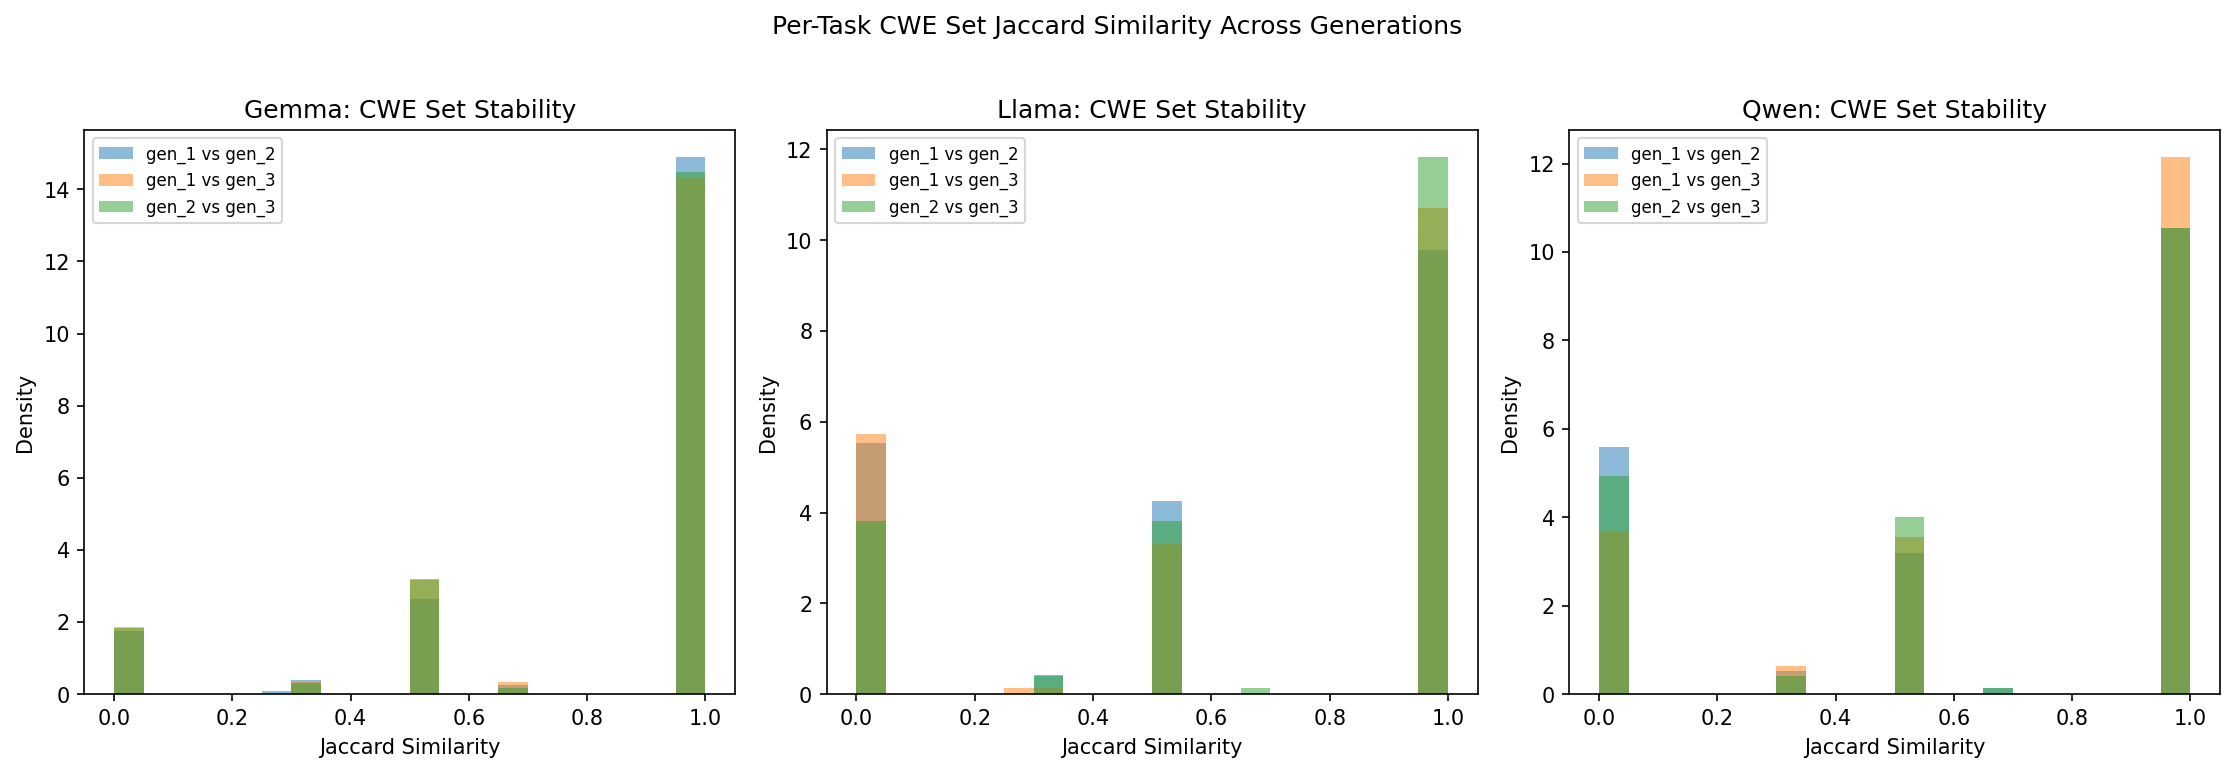

In [13]:
# Figure Q9: Jaccard similarity distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, model in enumerate(['gemma', 'llama', 'qwen']):
    ax = axes[idx]
    for g1, g2 in gen_pairs:
        s1 = cwe_sets[(cwe_sets['model'] == model) & (cwe_sets['generation'] == g1)]
        s2 = cwe_sets[(cwe_sets['model'] == model) & (cwe_sets['generation'] == g2)]
        merged = s1.merge(s2, on='problem_key', suffixes=('_1', '_2'))
        if len(merged) > 0:
            jacs = merged.apply(lambda r: jaccard(r['cwe_set_1'], r['cwe_set_2']), axis=1)
            ax.hist(jacs, bins=20, alpha=0.5, label=f'{g1} vs {g2}', density=True)
    ax.set_xlabel('Jaccard Similarity')
    ax.set_ylabel('Density')
    ax.set_title(f'{model.capitalize()}: CWE Set Stability')
    ax.legend(fontsize=8)

plt.suptitle('Per-Task CWE Set Jaccard Similarity Across Generations', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES}/q9_jaccard_cwe_distributions.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES}/q9_jaccard_cwe_distributions.png', bbox_inches='tight')
plt.show()

---
## Q11: Sensitivity Analysis (Excluding Inconclusive + Adding Clang-Tidy)

> "Do your conclusions change if inconclusive cppcheck warnings are excluded or if a second analyzer (e.g., clang-tidy) is added? Please provide a sensitivity analysis."

In [14]:
# Sensitivity analysis 1: CWE prevalence with vs without style/inconclusive cppcheck findings
# "Inconclusive" in cppcheck = style-level warnings (CWE-398 variableScope, CWE-563 unreadVariable)

# Full cppcheck: any CWE
full_cwe = master.groupby(['model', 'generation']).agg(
    n_analyzed=('sample_id', 'count'),
    n_with_cwe=('cppcheck_has_cwe', 'sum')
).reset_index()
full_cwe['prevalence_full'] = (full_cwe['n_with_cwe'] / full_cwe['n_analyzed']).round(3)

# Excluding style-only CWEs (CWE-398 and CWE-563)
style_cwes = {'398', '563', '398.0', '563.0'}

# Get programs with non-style CWEs from detailed data
non_style_cwe = cppcheck_det[~cppcheck_det['cwe'].astype(str).isin(style_cwes)].copy()
non_style_programs = non_style_cwe.groupby(['model', 'generation', 'sample_id']).size().reset_index()
non_style_programs.columns = ['model', 'generation', 'sample_id', 'n_findings']

non_style_by_mg = non_style_programs.groupby(['model', 'generation'])['sample_id'].nunique().reset_index()
non_style_by_mg.columns = ['model', 'generation', 'n_with_non_style_cwe']

sensitivity = full_cwe.merge(non_style_by_mg, on=['model', 'generation'], how='left')
sensitivity['n_with_non_style_cwe'] = sensitivity['n_with_non_style_cwe'].fillna(0).astype(int)
sensitivity['prevalence_excl_style'] = (sensitivity['n_with_non_style_cwe'] / sensitivity['n_analyzed']).round(3)

# Clang-tidy security prevalence (bugprone + analyzer > 0)
master['clang_security'] = master['clang_bugprone'].fillna(0) + master['clang_analyzer'].fillna(0)
clang_sec = master.groupby(['model', 'generation']).agg(
    n_with_clang_security=('clang_security', lambda x: (x > 0).sum())
).reset_index()

sensitivity = sensitivity.merge(clang_sec, on=['model', 'generation'], how='left')
sensitivity['prevalence_clang_security'] = (sensitivity['n_with_clang_security'] / sensitivity['n_analyzed']).round(3)

# Display
q11_cols = ['model', 'generation', 'n_analyzed', 'n_with_cwe', 'prevalence_full',
            'n_with_non_style_cwe', 'prevalence_excl_style',
            'n_with_clang_security', 'prevalence_clang_security']
q11 = sensitivity[q11_cols].copy()
q11.columns = ['Model', 'Generation', 'N Analyzed', 'N w/ Any CWE', 'Prevalence (all)',
               'N w/ Non-Style CWE', 'Prevalence (excl. style)',
               'N w/ Clang Security', 'Prevalence (clang security)']

q11.to_csv(f'{TABLES}/q11_sensitivity_analysis.csv', index=False)
print('Table Q11: Sensitivity Analysis — CWE Prevalence under Different Criteria')
q11

Table Q11: Sensitivity Analysis — CWE Prevalence under Different Criteria


,Model,Generation,N Analyzed,N w/ Any CWE,Prevalence (all),N w/ Non-Style CWE,Prevalence (excl. style),N w/ Clang Security,Prevalence (clang security)
0,gemma,gen_1,745,336,0.451,54,0.072,199,0.267
1,gemma,gen_2,740,345,0.466,52,0.070,215,0.291
2,gemma,gen_3,753,340,0.452,52,0.069,206,0.274
3,human,soln1,851,392,0.461,130,0.153,500,0.588
4,human,soln2,844,373,0.442,128,0.152,504,0.597
5,llama,gen_1,849,292,0.344,50,0.059,284,0.335
6,llama,gen_2,800,272,0.340,52,0.065,263,0.329
7,llama,gen_3,847,276,0.326,38,0.045,291,0.344
8,qwen,gen_1,850,279,0.328,36,0.042,252,0.296
9,qwen,gen_2,823,320,0.389,44,0.053,242,0.294


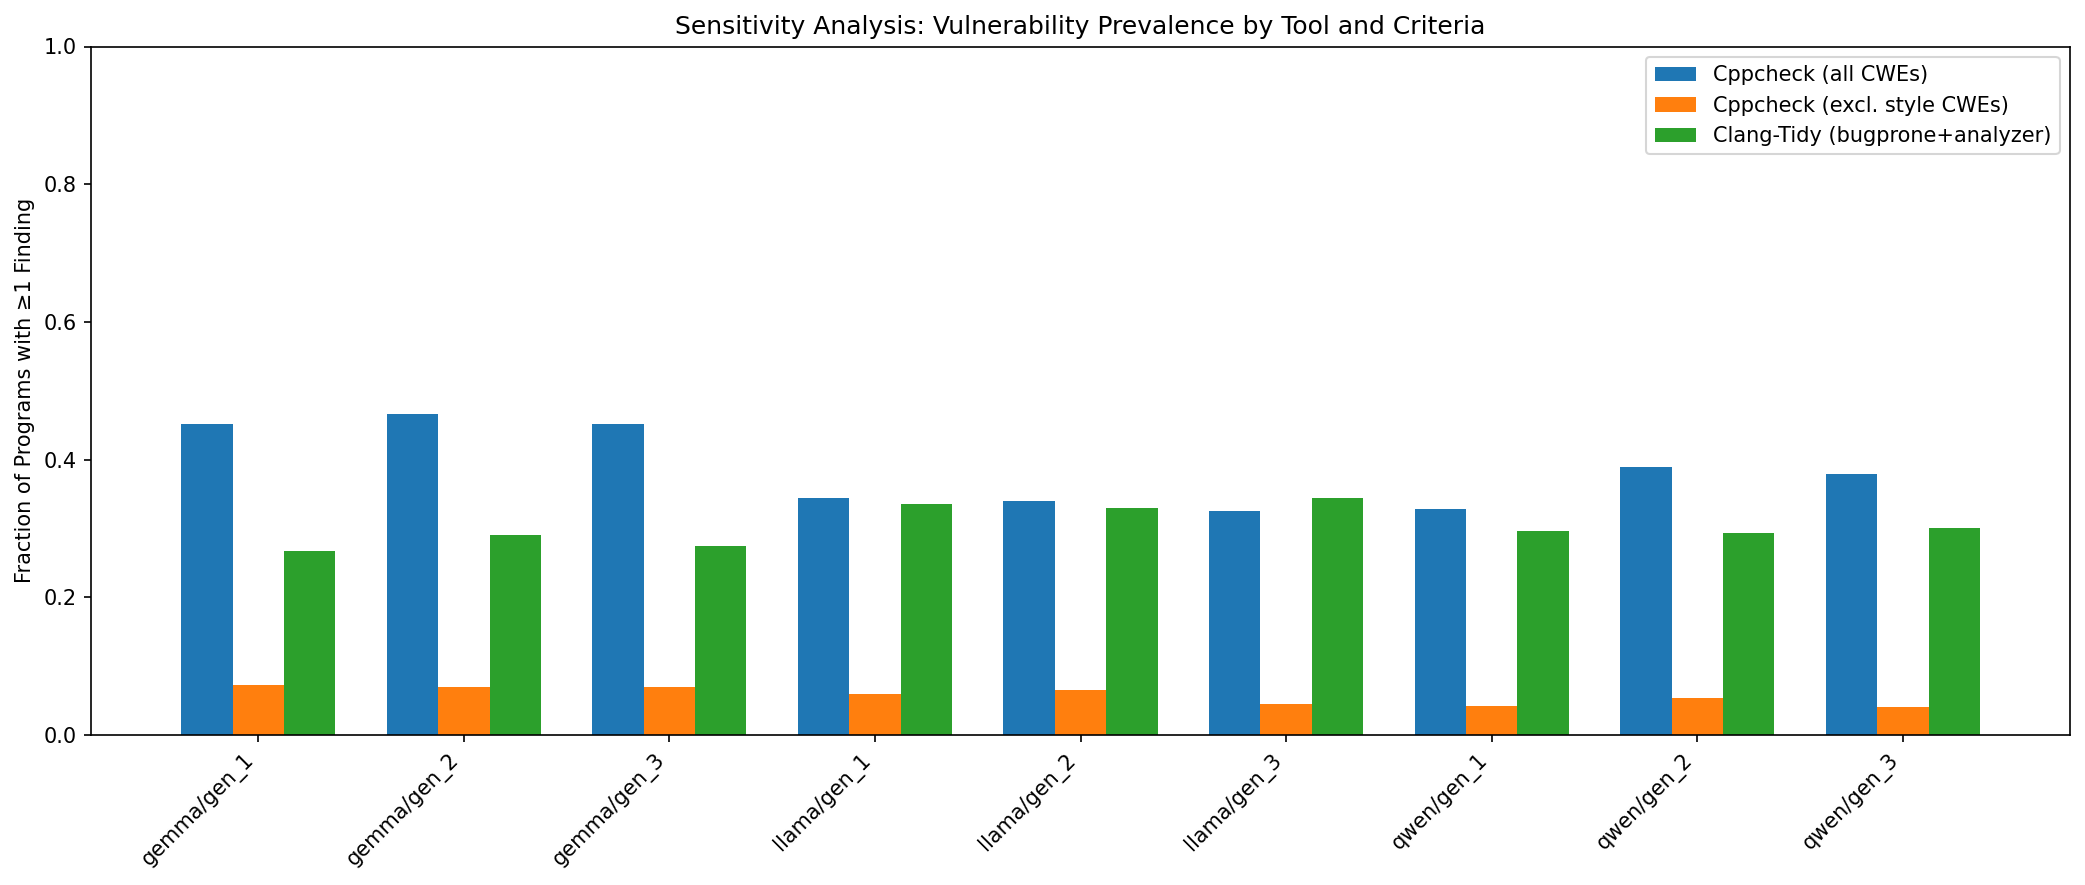

In [15]:
# Figure Q11: Side-by-side comparison of prevalence under different criteria
fig, ax = plt.subplots(figsize=(14, 6))

ai_sens = q11[~q11['Model'].isin(['human'])].copy()
ai_sens['label'] = ai_sens['Model'] + '/' + ai_sens['Generation']

x = np.arange(len(ai_sens))
w = 0.25

ax.bar(x - w, ai_sens['Prevalence (all)'].values, w, label='Cppcheck (all CWEs)', color='#1f77b4')
ax.bar(x, ai_sens['Prevalence (excl. style)'].values, w, label='Cppcheck (excl. style CWEs)', color='#ff7f0e')
ax.bar(x + w, ai_sens['Prevalence (clang security)'].values, w, label='Clang-Tidy (bugprone+analyzer)', color='#2ca02c')

ax.set_xticks(x)
ax.set_xticklabels(ai_sens['label'].values, rotation=45, ha='right')
ax.set_ylabel('Fraction of Programs with ≥1 Finding')
ax.set_title('Sensitivity Analysis: Vulnerability Prevalence by Tool and Criteria')
ax.legend()
ax.set_ylim(0, 1.0)
plt.tight_layout()
plt.savefig(f'{FIGURES}/q11_sensitivity_analysis.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES}/q11_sensitivity_analysis.png', bbox_inches='tight')
plt.show()

In [16]:
# Tool agreement analysis: programs flagged by cppcheck vs clang-tidy
master['has_cppcheck_cwe'] = master['cppcheck_has_cwe'].fillna(0).astype(bool)
master['has_clang_security'] = (master['clang_security'] > 0)

tool_agreement = []
for model in ['gemma', 'llama', 'qwen', 'human']:
    m = master[master['model'] == model]
    both = ((m['has_cppcheck_cwe']) & (m['has_clang_security'])).sum()
    cpp_only = ((m['has_cppcheck_cwe']) & (~m['has_clang_security'])).sum()
    clang_only = ((~m['has_cppcheck_cwe']) & (m['has_clang_security'])).sum()
    neither = ((~m['has_cppcheck_cwe']) & (~m['has_clang_security'])).sum()
    total = len(m)
    tool_agreement.append({
        'Model': model.capitalize(),
        'Both tools': both,
        'Cppcheck only': cpp_only,
        'Clang-tidy only': clang_only,
        'Neither': neither,
        'Total': total,
        'Agreement rate': round((both + neither) / total, 3)
    })

q11_agree = pd.DataFrame(tool_agreement)
q11_agree.to_csv(f'{TABLES}/q11_tool_agreement.csv', index=False)
print('Table Q11b: Tool Agreement (Cppcheck CWE vs Clang-Tidy Security)')
q11_agree

Table Q11b: Tool Agreement (Cppcheck CWE vs Clang-Tidy Security)


,Model,Both tools,Cppcheck only,Clang-tidy only,Neither,Total,Agreement rate
0,Gemma,360,661,260,957,2238,0.588
1,Llama,369,471,469,1187,2496,0.623
2,Qwen,364,544,376,1205,2489,0.630
3,Human,543,222,461,469,1695,0.597


---
## Q12: Correlation Between TPR and Static Warning Presence

> "Did you examine correlations between test pass rate and static warning presence at the program level? Are correct solutions systematically 'cleaner,' or is there no relationship?"

In [17]:
# Program-level correlation: pass_rate vs. warning counts
# Only include programs with test results (pass_rate is not NaN)
tested = master[master['pass_rate'].notna()].copy()

corr_metrics = [
    ('cppcheck_total', 'Cppcheck Total'),
    ('cppcheck_cwe_count', 'Cppcheck CWE Count'),
    ('clang_total', 'Clang-Tidy Total'),
    ('clang_bugprone', 'Clang-Tidy Bugprone'),
    ('clang_analyzer', 'Clang-Tidy Analyzer'),
]

# Overall correlation
corr_results = []
for col, label in corr_metrics:
    valid = tested[['pass_rate', col]].dropna()
    r_pearson, p_pearson = stats.pearsonr(valid['pass_rate'], valid[col])
    r_spearman, p_spearman = stats.spearmanr(valid['pass_rate'], valid[col])
    corr_results.append({
        'Metric': label,
        'Pearson r': round(r_pearson, 4),
        'Pearson p': f'{p_pearson:.2e}',
        'Spearman rho': round(r_spearman, 4),
        'Spearman p': f'{p_spearman:.2e}',
        'N': len(valid)
    })

q12_overall = pd.DataFrame(corr_results)
q12_overall.to_csv(f'{TABLES}/q12_tpr_warning_correlation_overall.csv', index=False)
print('Table Q12: Overall Correlation Between TPR and Static Warning Counts')
q12_overall

Table Q12: Overall Correlation Between TPR and Static Warning Counts


,Metric,Pearson r,Pearson p,Spearman rho,Spearman p,N
0,Cppcheck Total,-0.0415,3.44e-03,-0.0514,2.90e-04,4961
1,Cppcheck CWE Count,-0.0465,1.05e-03,-0.0433,2.30e-03,4961
2,Clang-Tidy Total,-0.0650,4.62e-06,-0.1019,6.34e-13,4961
3,Clang-Tidy Bugprone,0.0118,4.07e-01,-0.0369,9.38e-03,4961
4,Clang-Tidy Analyzer,0.0612,1.61e-05,0.0586,3.68e-05,4961


In [18]:
# Per-model correlation
per_model_corr = []
for model in ['gemma', 'llama', 'qwen', 'human']:
    m = tested[tested['model'] == model]
    for col, label in corr_metrics:
        valid = m[['pass_rate', col]].dropna()
        if len(valid) > 2:
            r, p = stats.spearmanr(valid['pass_rate'], valid[col])
            per_model_corr.append({
                'Model': model.capitalize(),
                'Metric': label,
                'Spearman rho': round(r, 4),
                'p-value': f'{p:.2e}',
                'N': len(valid)
            })

q12_by_model = pd.DataFrame(per_model_corr)
q12_by_model.to_csv(f'{TABLES}/q12_tpr_warning_correlation_by_model.csv', index=False)
print('Table Q12b: Per-Model Spearman Correlation Between TPR and Static Warnings')
q12_by_model

Table Q12b: Per-Model Spearman Correlation Between TPR and Static Warnings


,Model,Metric,Spearman rho,p-value,N
0,Gemma,Cppcheck Total,-0.1099,1.32e-04,1206
1,Gemma,Cppcheck CWE Count,-0.0941,1.07e-03,1206
2,Gemma,Clang-Tidy Total,-0.3676,6.84e-40,1206
3,Gemma,Clang-Tidy Bugprone,-0.1128,8.62e-05,1206
4,Gemma,Clang-Tidy Analyzer,-0.1175,4.30e-05,1206
5,Llama,Cppcheck Total,-0.0849,1.58e-03,1382
6,Llama,Cppcheck CWE Count,-0.0821,2.26e-03,1382
7,Llama,Clang-Tidy Total,-0.2640,1.77e-23,1382
8,Llama,Clang-Tidy Bugprone,-0.1884,1.65e-12,1382
9,Llama,Clang-Tidy Analyzer,-0.1442,7.29e-08,1382


In [19]:
# Compare mean warning counts: passing vs failing programs
tested['status'] = tested['pass_rate'].apply(
    lambda x: 'all_pass' if x == 1.0 else ('partial' if x > 0 else 'zero_pass')
)

status_comparison = []
for model in ['gemma', 'llama', 'qwen', 'human']:
    m = tested[tested['model'] == model]
    for status in ['all_pass', 'partial', 'zero_pass']:
        s = m[m['status'] == status]
        if len(s) > 0:
            status_comparison.append({
                'Model': model.capitalize(),
                'Status': status,
                'N': len(s),
                'Mean Cppcheck Total': round(s['cppcheck_total'].mean(), 3),
                'Mean Cppcheck CWE': round(s['cppcheck_cwe_count'].mean(), 3),
                'Mean Clang Total': round(s['clang_total'].mean(), 3),
                'Mean Clang Bugprone': round(s['clang_bugprone'].mean(), 3),
                'Mean Clang Analyzer': round(s['clang_analyzer'].mean(), 3),
            })

q12_status = pd.DataFrame(status_comparison)
q12_status.to_csv(f'{TABLES}/q12_warnings_by_pass_status.csv', index=False)
print('Table Q12c: Mean Warning Counts by Test Pass Status')
q12_status

Table Q12c: Mean Warning Counts by Test Pass Status


,Model,Status,N,Mean Cppcheck Total,Mean Cppcheck CWE,Mean Clang Total,Mean Clang Bugprone,Mean Clang Analyzer
0,Gemma,all_pass,269,0.595,0.394,3.751,0.219,0.059
1,Gemma,partial,727,1.175,0.565,7.459,0.399,0.116
2,Gemma,zero_pass,210,1.219,0.590,7.552,0.429,0.210
3,Llama,all_pass,289,0.308,0.242,3.180,0.215,0.010
4,Llama,partial,775,0.666,0.388,4.550,0.480,0.108
5,Llama,zero_pass,318,0.692,0.384,5.381,0.695,0.157
6,Qwen,all_pass,206,0.529,0.350,2.587,0.189,0.044
7,Qwen,partial,839,0.692,0.398,4.038,0.495,0.064
8,Qwen,zero_pass,334,1.036,0.530,5.105,0.620,0.171
9,Human,all_pass,748,1.214,0.579,7.846,1.344,0.544


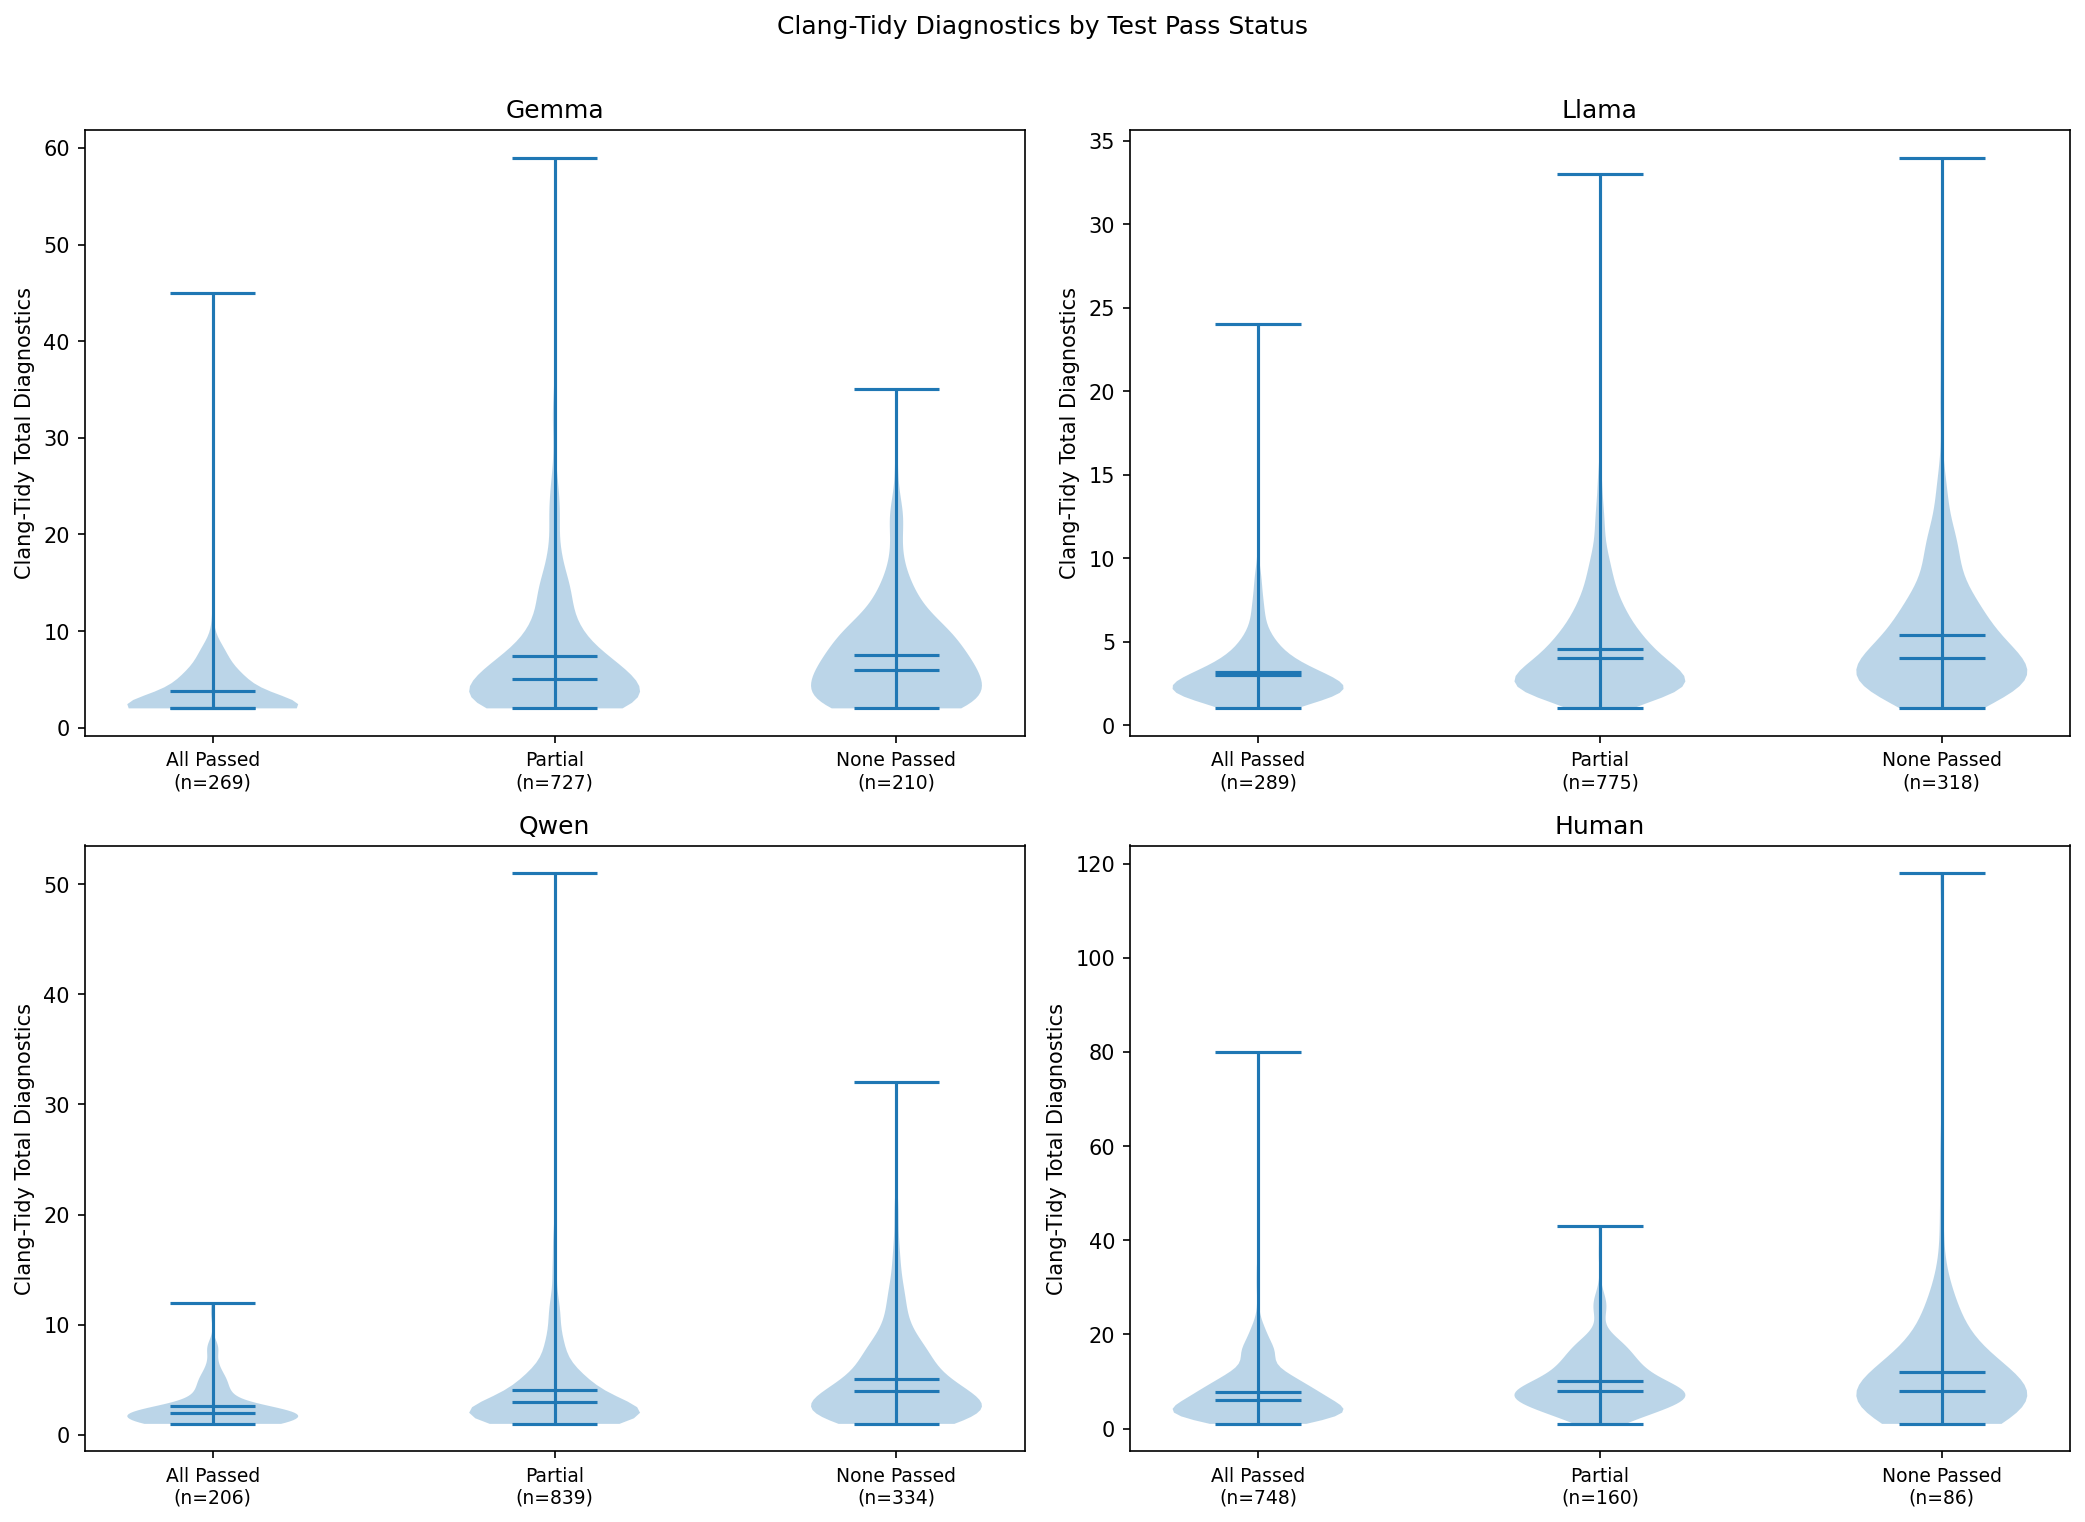

In [20]:
# Figure Q12: Violin plots of warning counts by pass status
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, model in enumerate(['gemma', 'llama', 'qwen', 'human']):
    ax = axes[idx // 2, idx % 2]
    m = tested[tested['model'] == model].copy()
    m['pass_status'] = m['pass_rate'].apply(
        lambda x: 'All Passed' if x == 1.0 else ('Partial' if x > 0 else 'None Passed')
    )

    data_by_status = []
    labels = []
    for status in ['All Passed', 'Partial', 'None Passed']:
        d = m[m['pass_status'] == status]['clang_total'].dropna()
        if len(d) > 0:
            data_by_status.append(d.values)
            labels.append(f'{status}\n(n={len(d)})')

    if data_by_status:
        vp = ax.violinplot(data_by_status, showmeans=True, showmedians=True)
        ax.set_xticks(range(1, len(labels) + 1))
        ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel('Clang-Tidy Total Diagnostics')
    ax.set_title(f'{model.capitalize()}')

plt.suptitle('Clang-Tidy Diagnostics by Test Pass Status', y=1.01)
plt.tight_layout()
plt.savefig(f'{FIGURES}/q12_warnings_by_status_violin.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES}/q12_warnings_by_status_violin.png', bbox_inches='tight')
plt.show()

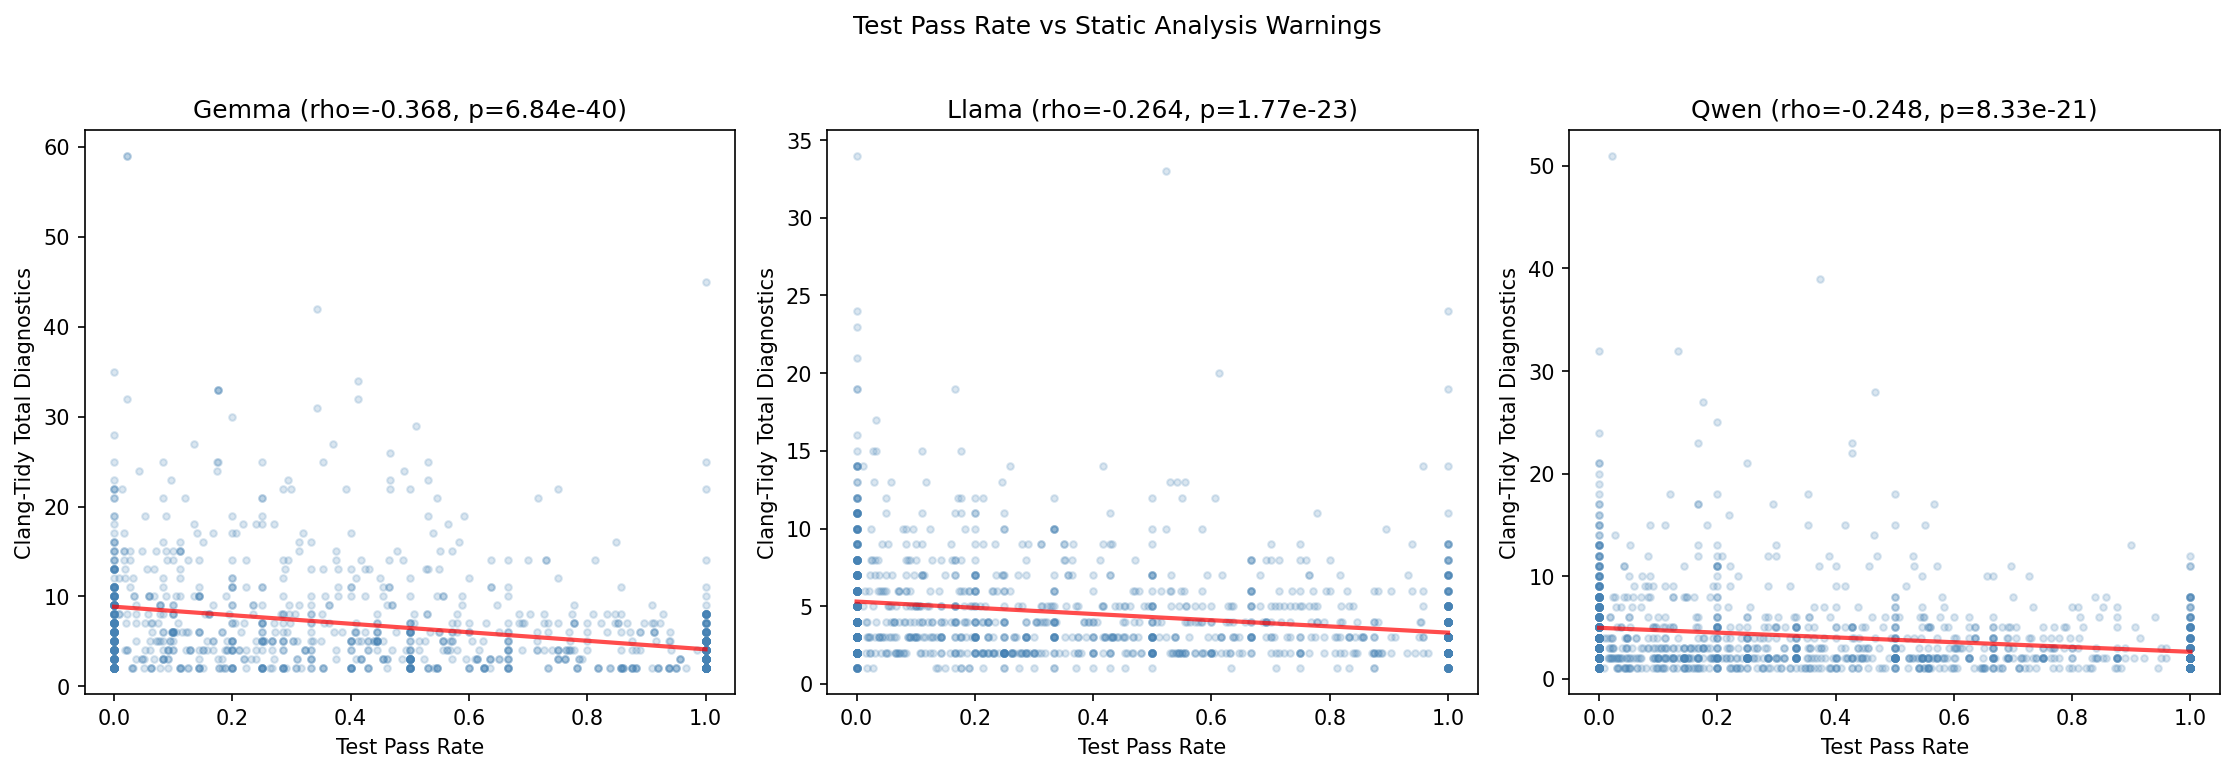

In [21]:
# Figure Q12b: Scatter plot of pass_rate vs clang_total (AI models only)
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, model in enumerate(['gemma', 'llama', 'qwen']):
    ax = axes[idx]
    m = tested[(tested['model'] == model)][['pass_rate', 'clang_total']].dropna()
    ax.scatter(m['pass_rate'], m['clang_total'], alpha=0.2, s=10, color='steelblue')

    # Add trend line
    z = np.polyfit(m['pass_rate'], m['clang_total'], 1)
    p_line = np.poly1d(z)
    x_line = np.linspace(0, 1, 100)
    ax.plot(x_line, p_line(x_line), 'r-', alpha=0.7, linewidth=2)

    r, p = stats.spearmanr(m['pass_rate'], m['clang_total'])
    ax.set_xlabel('Test Pass Rate')
    ax.set_ylabel('Clang-Tidy Total Diagnostics')
    ax.set_title(f'{model.capitalize()} (rho={r:.3f}, p={p:.2e})')

plt.suptitle('Test Pass Rate vs Static Analysis Warnings', y=1.02)
plt.tight_layout()
plt.savefig(f'{FIGURES}/q12_tpr_vs_clang.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES}/q12_tpr_vs_clang.png', bbox_inches='tight')
plt.show()

---
## Q3: Investigation of gen_2 TPR Drops

> "The gen_2 TPR drops (e.g., Gemma 0.040) are extreme. Did you identify any pipeline bug, environment change, or prompt alteration that explains this?"

In [22]:
# Investigate gen_2 behavior for all models
# Note: The paper reports Gemma TPR ~0.427 for gen_2, not 0.040.
# The reviewer may be referring to a specific tag or subset. Let's check.

# Overall TPR by model/generation
tpr_summary = tested.groupby(['model', 'generation']).agg(
    n=('pass_rate', 'count'),
    mean_tpr=('pass_rate', 'mean'),
    median_tpr=('pass_rate', 'median'),
    std_tpr=('pass_rate', 'std'),
    pct_zero=('pass_rate', lambda x: (x == 0).mean()),
    pct_all_pass=('pass_rate', lambda x: (x == 1.0).mean()),
).reset_index().round(3)

print('TPR Summary by Model/Generation:')
tpr_summary

TPR Summary by Model/Generation:


,model,generation,n,mean_tpr,median_tpr,std_tpr,pct_zero,pct_all_pass
0,gemma,gen_1,402,0.465,0.414,0.382,0.172,0.221
1,gemma,gen_2,400,0.459,0.414,0.373,0.175,0.210
2,gemma,gen_3,404,0.479,0.429,0.389,0.176,0.238
3,human,soln1,494,0.832,1.000,0.335,0.085,0.749
4,human,soln2,500,0.828,1.000,0.343,0.088,0.756
5,llama,gen_1,468,0.423,0.333,0.381,0.229,0.201
6,llama,gen_2,438,0.426,0.313,0.385,0.219,0.210
7,llama,gen_3,476,0.426,0.332,0.391,0.242,0.216
8,qwen,gen_1,479,0.361,0.250,0.352,0.238,0.134
9,qwen,gen_2,451,0.382,0.278,0.364,0.251,0.157


In [23]:
# Check if gen_2 has different characteristics: compile rate, code length, etc.
gen_comparison = tests.groupby(['model', 'generation']).agg(
    n=('sample_id', 'count'),
    compile_rate=('compiled', 'mean'),
    test_coverage=('has_tests', 'mean'),
    timeout_rate=('timeout', 'mean'),
    mean_total_tests=('total_tests', lambda x: x[x > 0].mean()),
).reset_index().round(3)

gen_comparison.to_csv(f'{TABLES}/q3_gen_comparison.csv', index=False)
print('Table Q3: Generation-Level Comparison')
gen_comparison

Table Q3: Generation-Level Comparison


,model,generation,n,compile_rate,test_coverage,timeout_rate,mean_total_tests
0,gemma,gen_1,745,0.897,0.540,0.075,26.756
1,gemma,gen_2,740,0.901,0.541,0.074,26.828
2,gemma,gen_3,753,0.907,0.537,0.068,26.733
3,human,soln1,851,0.976,0.580,0.006,25.856
4,human,soln2,844,0.988,0.592,0.005,26.094
5,llama,gen_1,849,0.899,0.551,0.059,26.630
6,llama,gen_2,800,0.920,0.548,0.061,26.954
7,llama,gen_3,847,0.913,0.562,0.061,26.294
8,qwen,gen_1,850,0.927,0.564,0.061,26.430
9,qwen,gen_2,823,0.905,0.548,0.064,25.831


---
## Summary of All Generated Outputs

---
## Dynamic Analysis (ASan/UBSan) Results

Tables and figures for sanitizer-based runtime error detection.

In [24]:
# Load sanitizer and ESBMC data
san_summary = pd.read_csv(f'{RAW}/sanitizer_summary.csv')
san_detailed = pd.read_csv(f'{RAW}/sanitizer_detailed.csv')
esbmc_summary = pd.read_csv(f'{RAW}/esbmc_summary.csv')
esbmc_violations = pd.read_csv(f'{RAW}/esbmc_violations.csv')
cross_ref = pd.read_csv(f'{RAW}/verification_cross_reference.csv')

print(f'Sanitizer summary: {len(san_summary)} rows')
print(f'Sanitizer detailed: {len(san_detailed)} rows')
print(f'ESBMC summary: {len(esbmc_summary)} rows')
print(f'ESBMC violations: {len(esbmc_violations)} rows')
print(f'Cross-reference: {len(cross_ref)} rows')

Sanitizer summary: 8918 rows
Sanitizer detailed: 131247 rows
ESBMC summary: 8918 rows
ESBMC violations: 661 rows
Cross-reference: 4295 rows


/tmp/ipykernel_28232/3771578404.py:3: DtypeWarning: Columns (8,9) have mixed types. Specify dtype option on import or set low_memory=False.
  san_detailed = pd.read_csv(f'{RAW}/sanitizer_detailed.csv')


In [25]:
# Table: Sanitizer trigger rate by model/generation
san_overview = san_summary.groupby(['model', 'generation']).agg(
    total=('sample_id', 'count'),
    compiled=('compiled', 'sum'),
    any_triggered=('any_sanitizer_triggered', 'sum'),
).reset_index()
san_overview['compile_rate'] = (san_overview['compiled'] / san_overview['total']).round(3)
san_overview['trigger_rate_of_compiled'] = (san_overview['any_triggered'] / san_overview['compiled']).round(3)
san_overview['trigger_rate_of_total'] = (san_overview['any_triggered'] / san_overview['total']).round(3)

san_overview.columns = ['Model', 'Generation', 'Total', 'Compiled', 'Triggered',
                        'Compile Rate', 'Trigger Rate (compiled)', 'Trigger Rate (total)']
san_overview.to_csv(f'{TABLES}/san_trigger_rate_by_model_gen.csv', index=False)
print('Table: Sanitizer Trigger Rate by Model/Generation')
san_overview

Table: Sanitizer Trigger Rate by Model/Generation


,Model,Generation,Total,Compiled,Triggered,Compile Rate,Trigger Rate (compiled),Trigger Rate (total)
0,gemma,gen_1,745,668,57,0.897,0.085,0.077
1,gemma,gen_2,740,667,55,0.901,0.082,0.074
2,gemma,gen_3,753,683,61,0.907,0.089,0.081
3,human,soln1,851,831,18,0.976,0.022,0.021
4,human,soln2,844,834,25,0.988,0.030,0.030
5,llama,gen_1,849,763,75,0.899,0.098,0.088
6,llama,gen_2,800,736,76,0.920,0.103,0.095
7,llama,gen_3,847,773,66,0.913,0.085,0.078
8,qwen,gen_1,850,788,79,0.927,0.100,0.093
9,qwen,gen_2,823,745,71,0.905,0.095,0.086


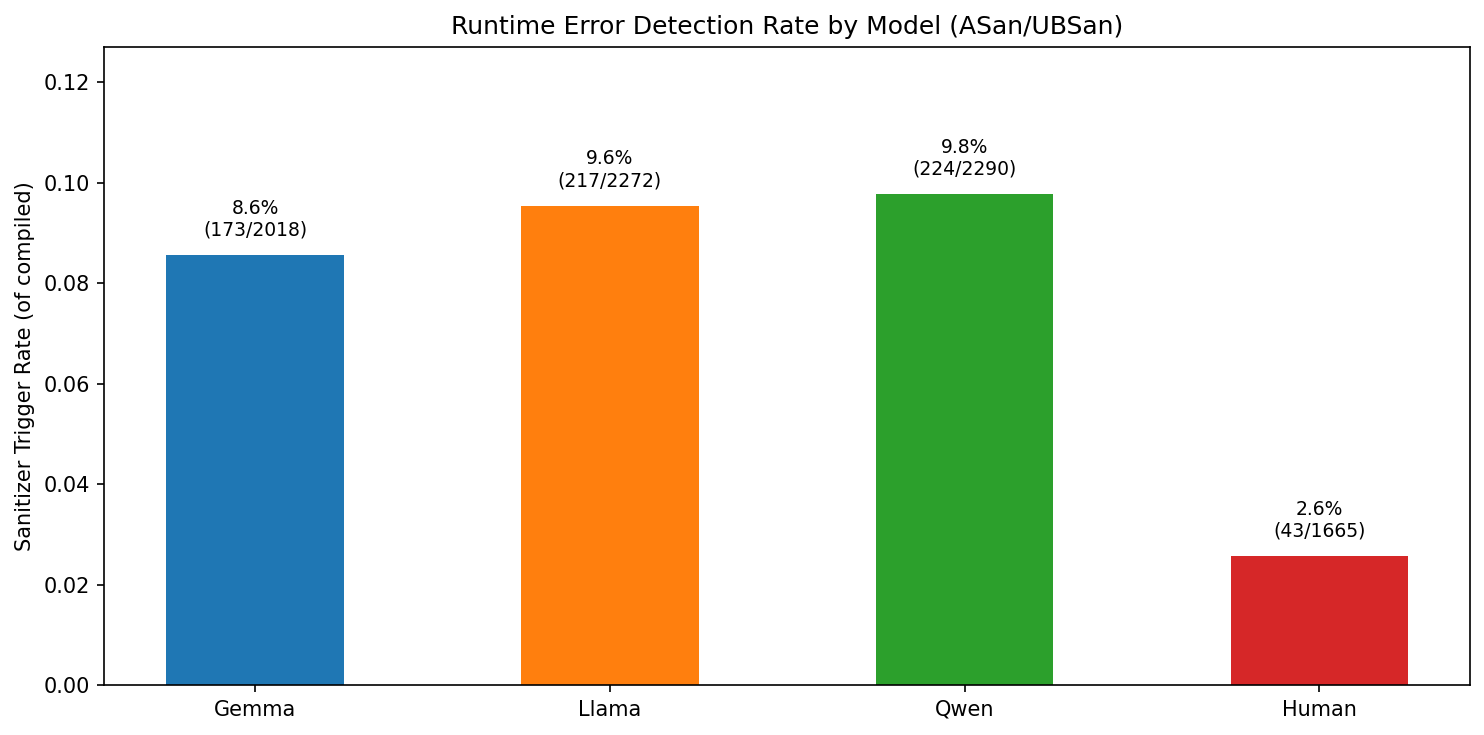

In [26]:
# Figure: Sanitizer trigger rate by model (grouped bar)
fig, ax = plt.subplots(figsize=(10, 5))

models = ['gemma', 'llama', 'qwen', 'human']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

model_rates = san_summary.groupby('model').agg(
    compiled=('compiled', 'sum'),
    triggered=('any_sanitizer_triggered', 'sum'),
    total=('sample_id', 'count')
).reset_index()
model_rates['trigger_rate'] = (model_rates['triggered'] / model_rates['compiled']).round(4)

bars = []
for m in models:
    row = model_rates[model_rates['model'] == m]
    bars.append(row['trigger_rate'].values[0] if len(row) > 0 else 0)

x = np.arange(len(models))
bar_objs = ax.bar(x, bars, color=colors, width=0.5)
ax.set_xticks(x)
ax.set_xticklabels([m.capitalize() for m in models])
ax.set_ylabel('Sanitizer Trigger Rate (of compiled)')
ax.set_title('Runtime Error Detection Rate by Model (ASan/UBSan)')
ax.set_ylim(0, max(bars) * 1.3)

for i, (b, v) in enumerate(zip(bar_objs, bars)):
    triggered = int(model_rates[model_rates['model'] == models[i]]['triggered'].values[0])
    compiled = int(model_rates[model_rates['model'] == models[i]]['compiled'].values[0])
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.003,
            f'{v:.1%}\n({triggered}/{compiled})', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES}/san_trigger_rate_by_model.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES}/san_trigger_rate_by_model.png', bbox_inches='tight')
plt.show()

In [38]:
# Table: Sanitizer CWE distribution
# Parse sanitizer_cwes column (pipe-separated CWE strings)
san_with_cwes = san_summary[san_summary['sanitizer_cwes'].notna() & (san_summary['sanitizer_cwes'] != '')].copy()

all_san_cwes = []
for _, row in san_with_cwes.iterrows():
    cwes = str(row['sanitizer_cwes']).split('|')
    for c in cwes:
        c = c.strip()
        if c:
            all_san_cwes.append({'model': row['model'], 'generation': row['generation'], 'cwe': c})

san_cwe_df = pd.DataFrame(all_san_cwes)

# Sanitizer CWE severity mapping
san_cwe_names = {
    'CWE-190': 'Integer Overflow',
    'CWE-122': 'Heap Buffer Overflow',
    'CWE-125': 'Out-of-bounds Read',
    'CWE-476': 'NULL Pointer Dereference',
    'CWE-369': 'Divide By Zero',
    'CWE-121': 'Stack Buffer Overflow',
    'CWE-416': 'Use After Free',
    'CWE-761': 'Free of Pointer not at Start of Buffer'
    
}

san_cwe_counts = san_cwe_df.groupby(['cwe', 'model']).size().reset_index(name='count')
san_cwe_pivot = san_cwe_counts.pivot_table(index='cwe', columns='model', values='count', fill_value=0).astype(int)
san_cwe_pivot['Total'] = san_cwe_pivot.sum(axis=1)
san_cwe_pivot['Description'] = san_cwe_pivot.index.map(lambda x: san_cwe_names.get(x, 'Unknown'))
san_cwe_pivot = san_cwe_pivot.sort_values('Total', ascending=False)

display_cols = ['Description', 'gemma', 'llama', 'qwen', 'human', 'Total']
san_cwe_display = san_cwe_pivot[[c for c in display_cols if c in san_cwe_pivot.columns]]
san_cwe_display.to_csv(f'{TABLES}/san_cwe_distribution.csv')
print('Table: Sanitizer CWE Distribution by Model')
san_cwe_display

Table: Sanitizer CWE Distribution by Model


model,Description,gemma,llama,qwen,human,Total
cwe,,,,,,
CWE-190,Integer Overflow,144,99,89,11,343
CWE-122,Heap Buffer Overflow,20,62,75,4,161
CWE-125,Out-of-bounds Read,0,25,26,20,71
CWE-476,NULL Pointer Dereference,7,16,16,0,39
CWE-369,Divide By Zero,1,14,10,0,25
CWE-121,Stack Buffer Overflow,4,3,6,0,13
CWE-416,Use After Free,0,2,2,1,5
CWE-761,Free of Pointer not at Start of Buffer,0,0,1,0,1


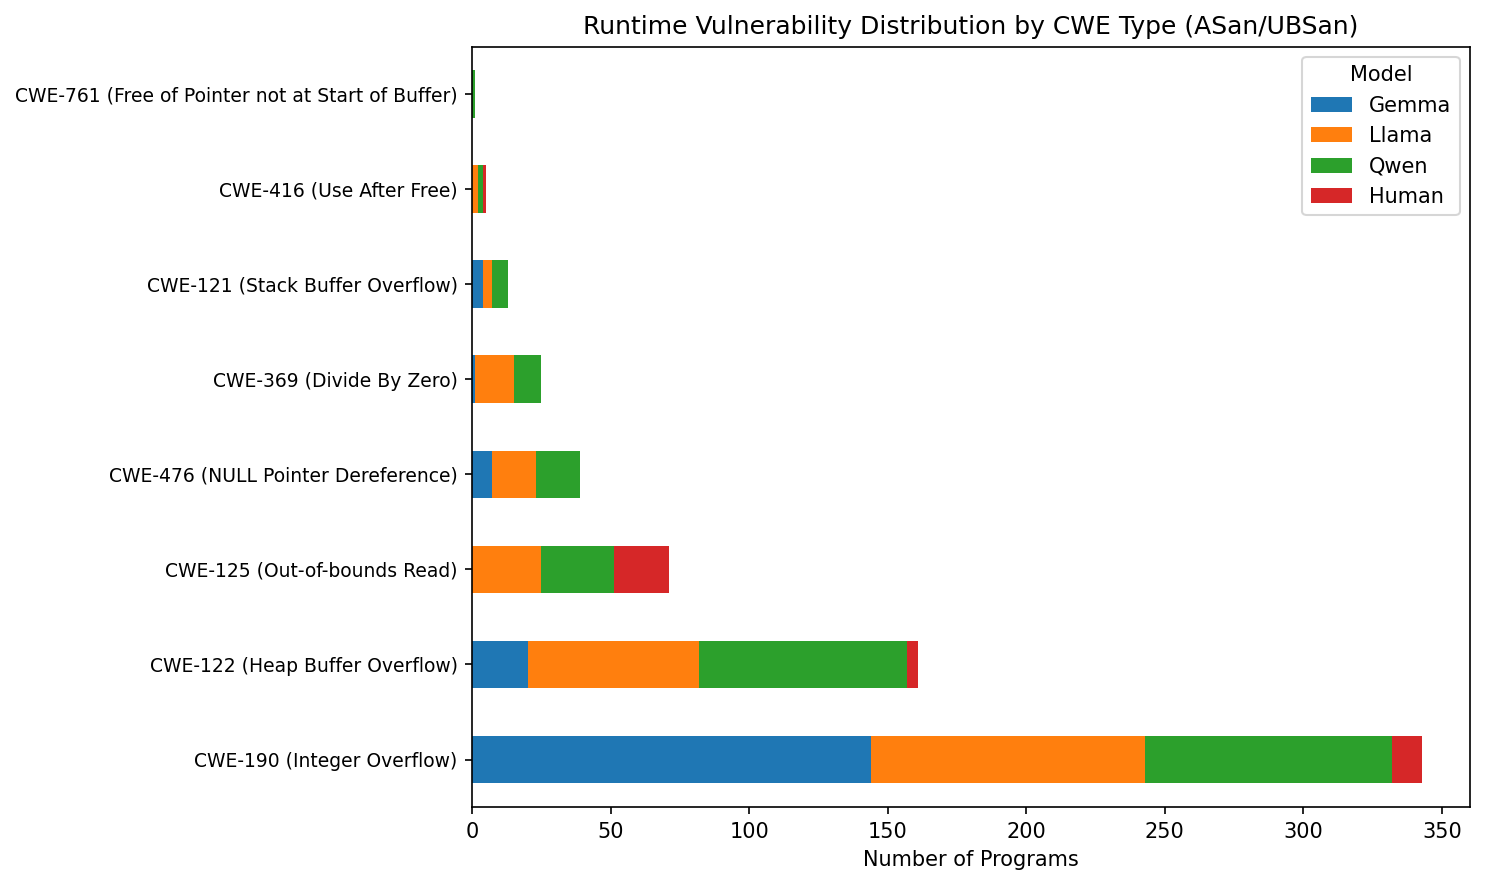

In [39]:
# Figure: Sanitizer CWE distribution (stacked bar by model)
fig, ax = plt.subplots(figsize=(10, 6))

san_cwe_plot = san_cwe_display.drop(columns=['Description', 'Total'], errors='ignore')
san_cwe_plot.plot(kind='barh', stacked=True, ax=ax, 
                  color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
ax.set_xlabel('Number of Programs')
ax.set_ylabel('')
# Add description labels
labels = [f"{idx} ({san_cwe_names.get(idx, '')})" for idx in san_cwe_plot.index]
ax.set_yticklabels(labels, fontsize=9)
ax.set_title('Runtime Vulnerability Distribution by CWE Type (ASan/UBSan)')
ax.legend(title='Model', labels=[m.capitalize() for m in san_cwe_plot.columns])
plt.tight_layout()
plt.savefig(f'{FIGURES}/san_cwe_distribution.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES}/san_cwe_distribution.png', bbox_inches='tight')
plt.show()

---
## Formal Verification (ESBMC) Results

Tables and figures for bounded model checking results.

In [40]:
# Table: ESBMC verdict distribution by model/generation
esbmc_overview = esbmc_summary.groupby(['model', 'generation', 'verdict']).size().reset_index(name='count')
esbmc_pivot = esbmc_overview.pivot_table(index=['model', 'generation'], columns='verdict', 
                                          values='count', fill_value=0).astype(int)
esbmc_pivot['total'] = esbmc_pivot.sum(axis=1)

# Compute rates
for col in ['FAILED', 'SUCCESS', 'PARSE_ERROR', 'TIMEOUT']:
    if col in esbmc_pivot.columns:
        esbmc_pivot[f'{col}_rate'] = (esbmc_pivot[col] / esbmc_pivot['total']).round(3)

# Analyzable = SUCCESS + FAILED (excludes PARSE_ERROR and TIMEOUT)
esbmc_pivot['analyzable'] = esbmc_pivot.get('SUCCESS', 0) + esbmc_pivot.get('FAILED', 0)
esbmc_pivot['coverage_rate'] = (esbmc_pivot['analyzable'] / esbmc_pivot['total']).round(3)
esbmc_pivot['failure_rate_of_analyzable'] = np.where(
    esbmc_pivot['analyzable'] > 0,
    (esbmc_pivot.get('FAILED', 0) / esbmc_pivot['analyzable']).round(3),
    0
)

esbmc_pivot.to_csv(f'{TABLES}/esbmc_verdict_by_model_gen.csv')
print('Table: ESBMC Verdict Distribution by Model/Generation')
esbmc_pivot

Table: ESBMC Verdict Distribution by Model/Generation


verdict           ERROR  FAILED  PARSE_ERROR  SUCCESS  TIMEOUT  total  \
model generation                                                        
gemma gen_1           0      73          175      225      272    745   
      gen_2           0      81          173      221      265    740   
      gen_3           0      80          159      224      290    753   
human soln1           1       7          766       44       33    851   
      soln2           2      14          757       47       24    844   
llama gen_1           2      83          477      154      133    849   
      gen_2           1      92          393      154      160    800   
      gen_3           1      96          416      160      174    847   
qwen  gen_1          18      33          694       74       31    850   
      gen_2          11      55          511      122      124    823   
      gen_3          10      47          518      126      115    816   

verdict           FAILED_rate  SUCCESS_rate  PARSE_ERROR_rate  TIMEOUT_rate  \
model generation                                                              
gemma gen_1             0.098         0.302             0.235         0.365   
      gen_2             0.109         0.299             0.234         0.358   
      gen_3             0.106         0.297             0.211         0.385   
human soln1             0.008         0.052             0.900         0.039   
      soln2             0.017         0.056             0.897         0.028   
llama gen_1             0.098         0.181             0.562         0.157   
      gen_2             0.115         0.192             0.491         0.200   
      gen_3             0.113         0.189             0.491         0.205   
qwen  gen_1             0.039         0.087             0.816         0.036   
      gen_2             0.067         0.148             0.621         0.151   
      gen_3             0.058         0.154             0.635         0.141   

verdict           analyzable  coverage_rate  failure_rate_of_analyzable  
model generation                                                         
gemma gen_1              298          0.400                       0.245  
      gen_2              302          0.408                       0.268  
      gen_3              304          0.404                       0.263  
human soln1               51          0.060                       0.137  
      soln2               61          0.072                       0.230  
llama gen_1              237          0.279                       0.350  
      gen_2              246          0.308                       0.374  
      gen_3              256          0.302                       0.375  
qwen  gen_1              107          0.126                       0.308  
      gen_2              177          0.215                       0.311  
      gen_3              173          0.212                       0.272

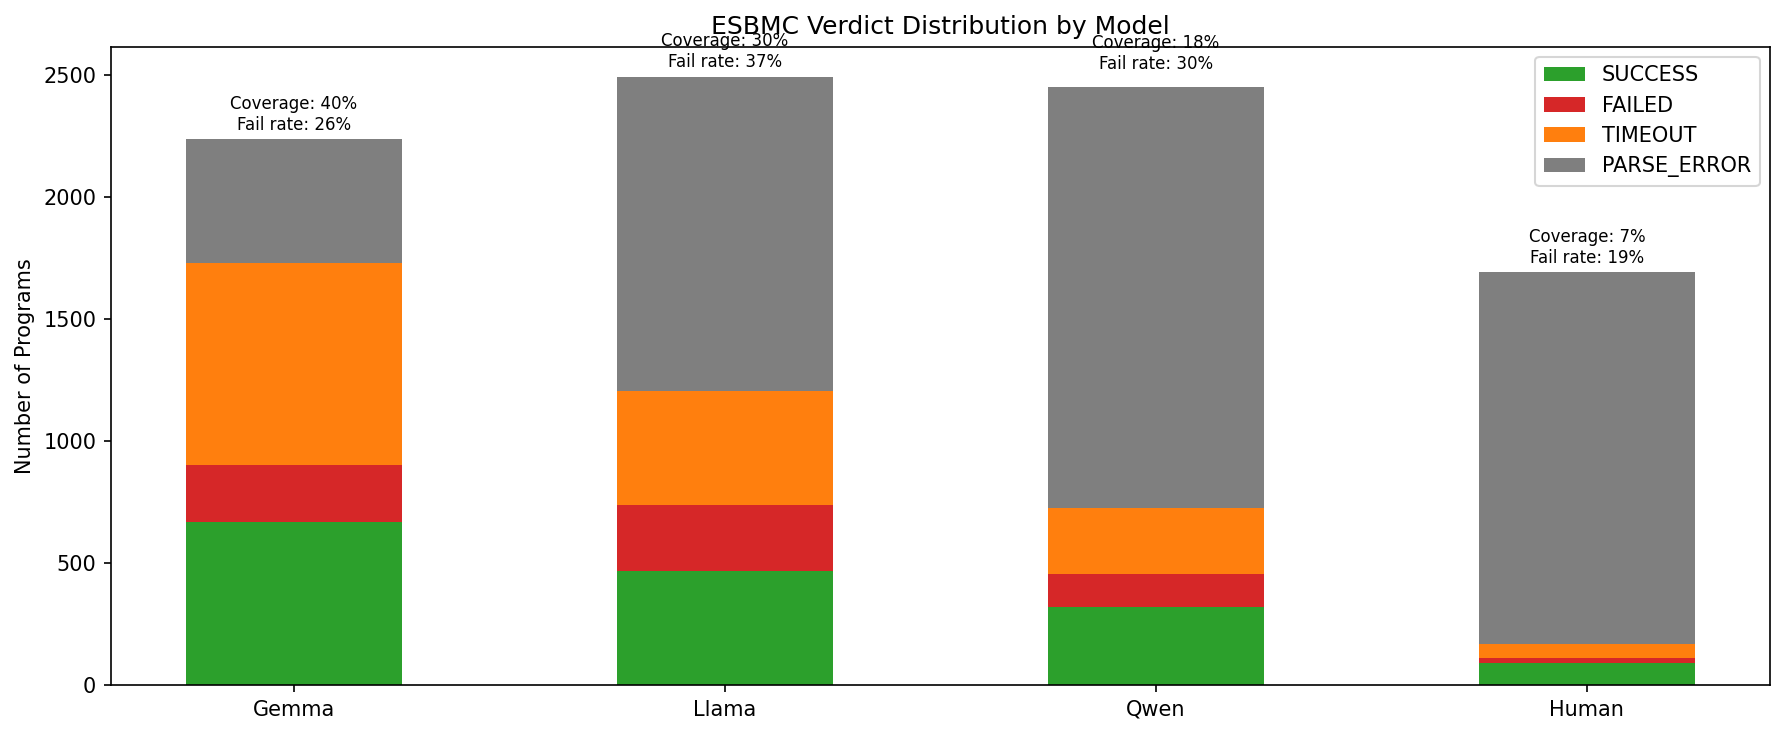

In [41]:
# Figure: ESBMC verdict distribution (stacked bar by model)
fig, ax = plt.subplots(figsize=(12, 5))

esbmc_by_model = esbmc_summary.groupby(['model', 'verdict']).size().reset_index(name='count')
esbmc_model_pivot = esbmc_by_model.pivot_table(index='model', columns='verdict', values='count', fill_value=0)

# Reorder
model_order = ['gemma', 'llama', 'qwen', 'human']
verdict_order = ['SUCCESS', 'FAILED', 'TIMEOUT', 'PARSE_ERROR']
verdict_colors = {'SUCCESS': '#2ca02c', 'FAILED': '#d62728', 'TIMEOUT': '#ff7f0e', 'PARSE_ERROR': '#7f7f7f'}

esbmc_model_pivot = esbmc_model_pivot.reindex(model_order)
bottom = np.zeros(len(model_order))

for verdict in verdict_order:
    if verdict in esbmc_model_pivot.columns:
        vals = esbmc_model_pivot[verdict].values
        ax.bar(range(len(model_order)), vals, bottom=bottom, 
               label=verdict, color=verdict_colors[verdict], width=0.5)
        bottom += vals

ax.set_xticks(range(len(model_order)))
ax.set_xticklabels([m.capitalize() for m in model_order])
ax.set_ylabel('Number of Programs')
ax.set_title('ESBMC Verdict Distribution by Model')
ax.legend()

# Add percentage labels for FAILED
for i, model in enumerate(model_order):
    total = esbmc_model_pivot.loc[model].sum()
    failed = esbmc_model_pivot.loc[model].get('FAILED', 0)
    analyzable = esbmc_model_pivot.loc[model].get('SUCCESS', 0) + failed
    ax.text(i, total + 20, f'Coverage: {analyzable/total:.0%}\nFail rate: {failed/max(analyzable,1):.0%}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f'{FIGURES}/esbmc_verdict_by_model.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES}/esbmc_verdict_by_model.png', bbox_inches='tight')
plt.show()

In [42]:
# Table: ESBMC CWE distribution from violations
esbmc_cwes_list = []
for _, row in esbmc_violations.iterrows():
    if pd.notna(row['cwes']) and str(row['cwes']).strip():
        for c in str(row['cwes']).split('|'):
            c = c.strip()
            if c:
                esbmc_cwes_list.append({'model': row['model'], 'cwe': c})

esbmc_cwe_df = pd.DataFrame(esbmc_cwes_list)

esbmc_cwe_names = {
    'CWE-119': 'Buffer Overflow (generic)',
    'CWE-476': 'NULL Pointer Dereference',
    'CWE-190': 'Integer Overflow',
    'CWE-825': 'Expired Pointer Dereference',
    'CWE-457': 'Use of Uninitialized Variable',
}

if len(esbmc_cwe_df) > 0:
    esbmc_cwe_counts = esbmc_cwe_df.groupby(['cwe', 'model']).size().reset_index(name='count')
    esbmc_cwe_pivot = esbmc_cwe_counts.pivot_table(index='cwe', columns='model', values='count', fill_value=0).astype(int)
    esbmc_cwe_pivot['Total'] = esbmc_cwe_pivot.sum(axis=1)
    esbmc_cwe_pivot['Description'] = esbmc_cwe_pivot.index.map(lambda x: esbmc_cwe_names.get(x, 'Unknown'))
    esbmc_cwe_pivot = esbmc_cwe_pivot.sort_values('Total', ascending=False)
    esbmc_cwe_pivot.to_csv(f'{TABLES}/esbmc_cwe_distribution.csv')
    print('Table: ESBMC CWE Distribution')
    esbmc_cwe_pivot
else:
    print('No CWEs found in ESBMC violations')

Table: ESBMC CWE Distribution


---
## Cross-Tool Comparison (RQ3)

Tier 1: Cppcheck vs Sanitizer (full coverage, n=8,918)  
Tier 2: All three tools on ESBMC-analyzable subset

In [43]:
# Tier 1: Cppcheck vs Sanitizer (all 8,918 files)
# Merge sanitizer and master (which has cppcheck data)
tier1 = san_summary[['sample_id', 'model', 'generation', 'compiled', 
                      'any_sanitizer_triggered', 'sanitizer_cwes']].merge(
    master[['sample_id', 'cppcheck_has_cwe', 'cppcheck_cwe_count']], 
    on='sample_id', how='left'
)

tier1['san_flag'] = tier1['any_sanitizer_triggered'].fillna(0).astype(bool)
tier1['cpp_flag'] = tier1['cppcheck_has_cwe'].fillna(0).astype(bool)

# Tier 1 agreement table by model
tier1_agreement = []
for model in ['gemma', 'llama', 'qwen', 'human']:
    m = tier1[tier1['model'] == model]
    both = ((m['san_flag']) & (m['cpp_flag'])).sum()
    san_only = ((m['san_flag']) & (~m['cpp_flag'])).sum()
    cpp_only = ((~m['san_flag']) & (m['cpp_flag'])).sum()
    neither = ((~m['san_flag']) & (~m['cpp_flag'])).sum()
    total = len(m)
    tier1_agreement.append({
        'Model': model.capitalize(),
        'Both (cppcheck + sanitizer)': both,
        'Cppcheck CWE only': cpp_only,
        'Sanitizer only': san_only,
        'Neither': neither,
        'Total': total,
        'Any finding': both + san_only + cpp_only,
        'Any finding rate': round((both + san_only + cpp_only) / total, 3),
    })

tier1_df = pd.DataFrame(tier1_agreement)
tier1_df.to_csv(f'{TABLES}/cross_tool_tier1_cppcheck_vs_sanitizer.csv', index=False)
print('Table: Tier 1 Cross-Tool Agreement — Cppcheck vs Sanitizer (n=8,918)')
tier1_df

Table: Tier 1 Cross-Tool Agreement — Cppcheck vs Sanitizer (n=8,918)


,Model,Both (cppcheck + sanitizer),Cppcheck CWE only,Sanitizer only,Neither,Total,Any finding,Any finding rate
0,Gemma,95,926,78,1139,2238,1099,0.491
1,Llama,76,764,141,1515,2496,981,0.393
2,Qwen,100,808,124,1457,2489,1032,0.415
3,Human,31,734,12,918,1695,777,0.458


In [44]:
# Tier 2: Three-way comparison on ESBMC-analyzable subset
# Filter cross_ref to only ESBMC-analyzable (SUCCESS or FAILED)
tier2 = cross_ref[cross_ref['esbmc_verdict'].isin(['SUCCESS', 'FAILED'])].copy()

tier2['esbmc_flag'] = tier2['esbmc_verdict'] == 'FAILED'
tier2['san_flag'] = tier2['sanitizer_triggered'].fillna(0).astype(bool)
tier2['cpp_flag'] = tier2['cppcheck_cwes'].notna() & (tier2['cppcheck_cwes'] != '')

# Three-way breakdown by model
tier2_agreement = []
for model in ['gemma', 'llama', 'qwen', 'human']:
    m = tier2[tier2['model'] == model]
    if len(m) == 0:
        continue
    all_three = ((m['esbmc_flag']) & (m['san_flag']) & (m['cpp_flag'])).sum()
    esbmc_san = ((m['esbmc_flag']) & (m['san_flag']) & (~m['cpp_flag'])).sum()
    esbmc_cpp = ((m['esbmc_flag']) & (~m['san_flag']) & (m['cpp_flag'])).sum()
    san_cpp = ((~m['esbmc_flag']) & (m['san_flag']) & (m['cpp_flag'])).sum()
    esbmc_only = ((m['esbmc_flag']) & (~m['san_flag']) & (~m['cpp_flag'])).sum()
    san_only = ((~m['esbmc_flag']) & (m['san_flag']) & (~m['cpp_flag'])).sum()
    cpp_only = ((~m['esbmc_flag']) & (~m['san_flag']) & (m['cpp_flag'])).sum()
    clean = ((~m['esbmc_flag']) & (~m['san_flag']) & (~m['cpp_flag'])).sum()
    
    tier2_agreement.append({
        'Model': model.capitalize(),
        'N (analyzable)': len(m),
        'All 3 tools': all_three,
        'ESBMC + Sanitizer': esbmc_san,
        'ESBMC + Cppcheck': esbmc_cpp,
        'Sanitizer + Cppcheck': san_cpp,
        'ESBMC only': esbmc_only,
        'Sanitizer only': san_only,
        'Cppcheck only': cpp_only,
        'Clean (none)': clean,
        'Any finding': len(m) - clean,
        'Any finding rate': round((len(m) - clean) / len(m), 3),
    })

tier2_df = pd.DataFrame(tier2_agreement)
tier2_df.to_csv(f'{TABLES}/cross_tool_tier2_three_way.csv', index=False)
print('Table: Tier 2 Three-Way Cross-Tool Agreement (ESBMC-analyzable subset)')
tier2_df

Table: Tier 2 Three-Way Cross-Tool Agreement (ESBMC-analyzable subset)


,Model,N (analyzable),All 3 tools,ESBMC + Sanitizer,ESBMC + Cppcheck,Sanitizer + Cppcheck,ESBMC only,Sanitizer only,Cppcheck only,Clean (none),Any finding,Any finding rate
0,Gemma,499,15,17,59,23,143,18,224,0,499,1.0
1,Llama,395,6,11,69,9,185,24,91,0,395,1.0
2,Qwen,225,6,8,38,3,83,6,81,0,225,1.0
3,Human,56,0,0,8,0,13,0,35,0,56,1.0


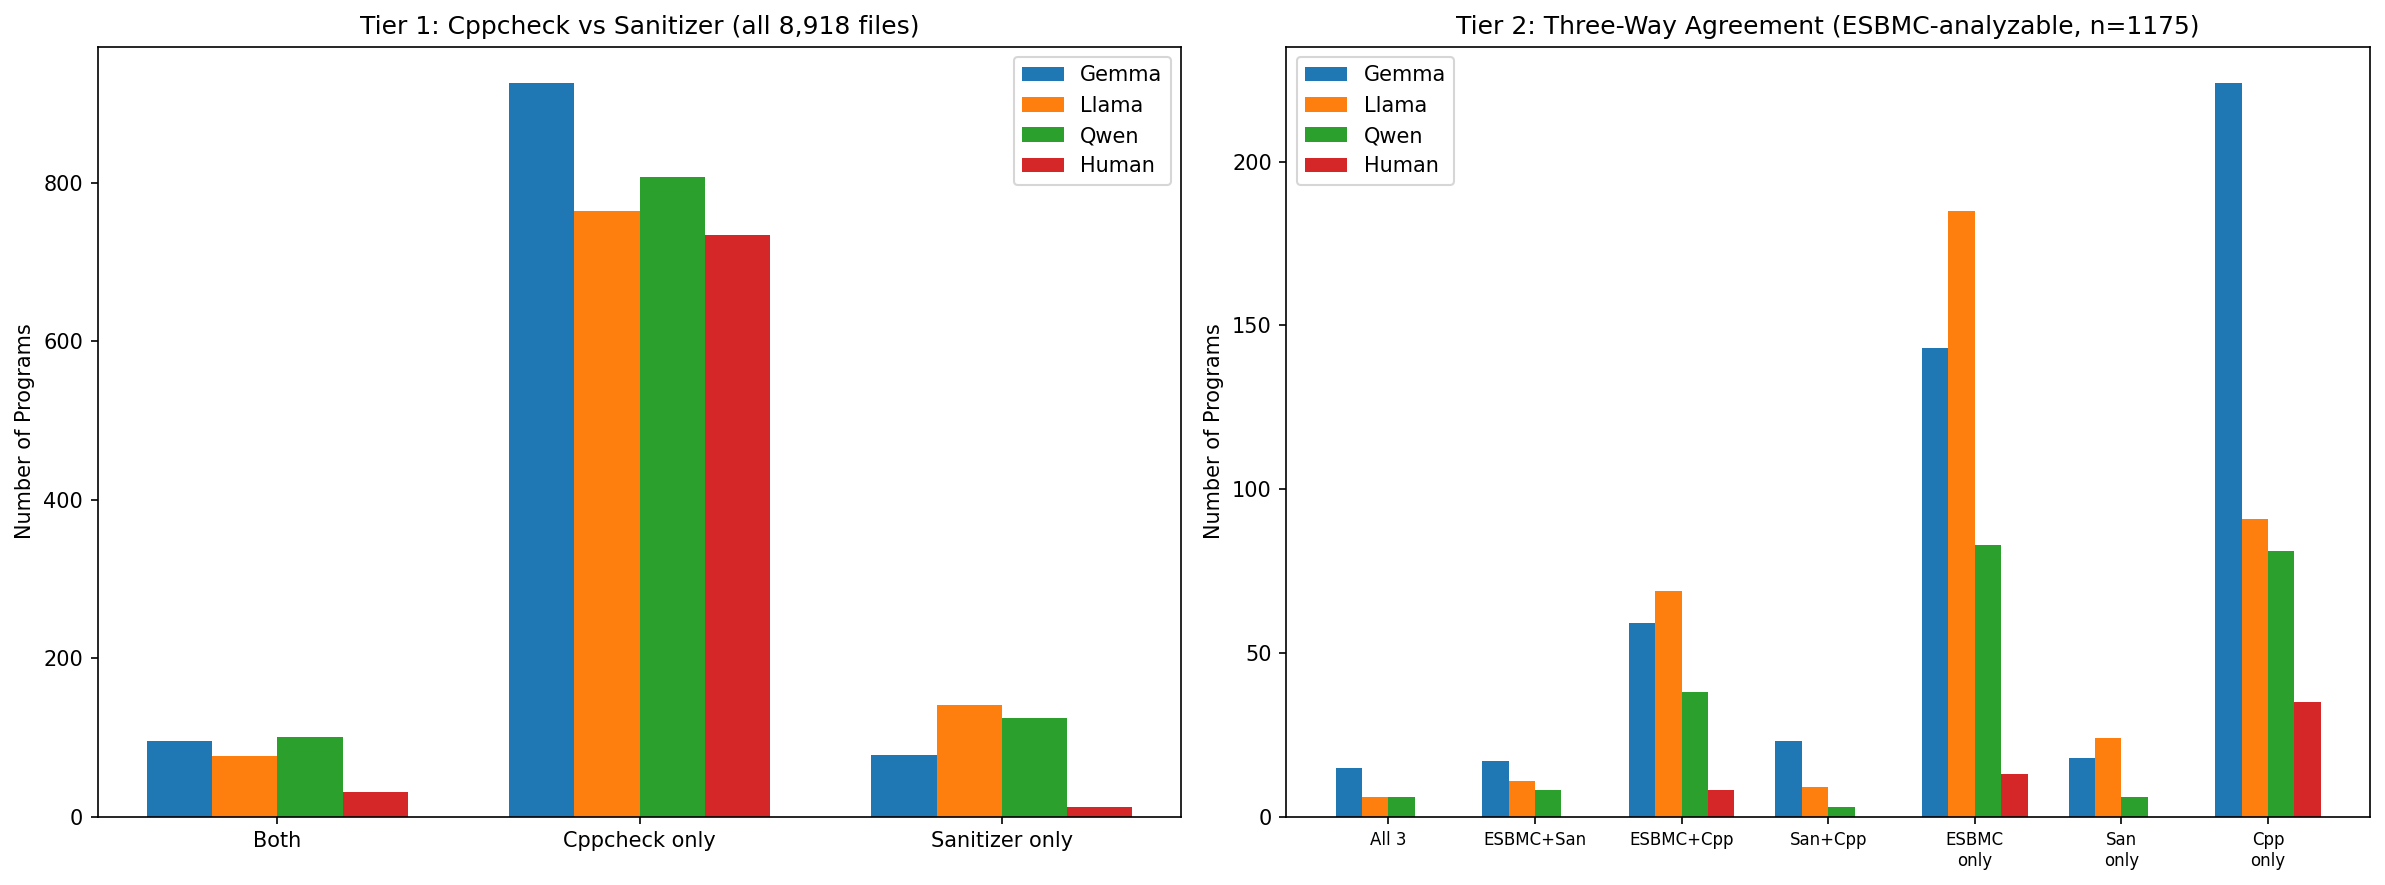

In [45]:
# Figure: Cross-tool Venn-style summary (grouped bar — findings by tool combination)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Tier 1 — Cppcheck vs Sanitizer
ax = axes[0]
categories = ['Both', 'Cppcheck only', 'Sanitizer only']
models_list = ['Gemma', 'Llama', 'Qwen', 'Human']
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
x = np.arange(len(categories))
w = 0.18

for i, (model, color) in enumerate(zip(models_list, colors)):
    row = tier1_df[tier1_df['Model'] == model].iloc[0]
    vals = [row['Both (cppcheck + sanitizer)'], row['Cppcheck CWE only'], row['Sanitizer only']]
    ax.bar(x + i * w, vals, w, label=model, color=color)

ax.set_xticks(x + 1.5 * w)
ax.set_xticklabels(categories)
ax.set_ylabel('Number of Programs')
ax.set_title('Tier 1: Cppcheck vs Sanitizer (all 8,918 files)')
ax.legend()

# Right: Tier 2 — Three-way on ESBMC-analyzable
ax = axes[1]
categories2 = ['All 3', 'ESBMC+San', 'ESBMC+Cpp', 'San+Cpp', 'ESBMC\nonly', 'San\nonly', 'Cpp\nonly']

for i, (model, color) in enumerate(zip(models_list, colors)):
    row_data = tier2_df[tier2_df['Model'] == model]
    if len(row_data) == 0:
        continue
    row = row_data.iloc[0]
    vals = [row['All 3 tools'], row['ESBMC + Sanitizer'], row['ESBMC + Cppcheck'],
            row['Sanitizer + Cppcheck'], row['ESBMC only'], row['Sanitizer only'], row['Cppcheck only']]
    x2 = np.arange(len(categories2))
    ax.bar(x2 + i * w, vals, w, label=model, color=color)

ax.set_xticks(x2 + 1.5 * w)
ax.set_xticklabels(categories2, fontsize=8)
ax.set_ylabel('Number of Programs')
ax.set_title(f'Tier 2: Three-Way Agreement (ESBMC-analyzable, n={len(tier2)})')
ax.legend()

plt.tight_layout()
plt.savefig(f'{FIGURES}/cross_tool_comparison.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES}/cross_tool_comparison.png', bbox_inches='tight')
plt.show()

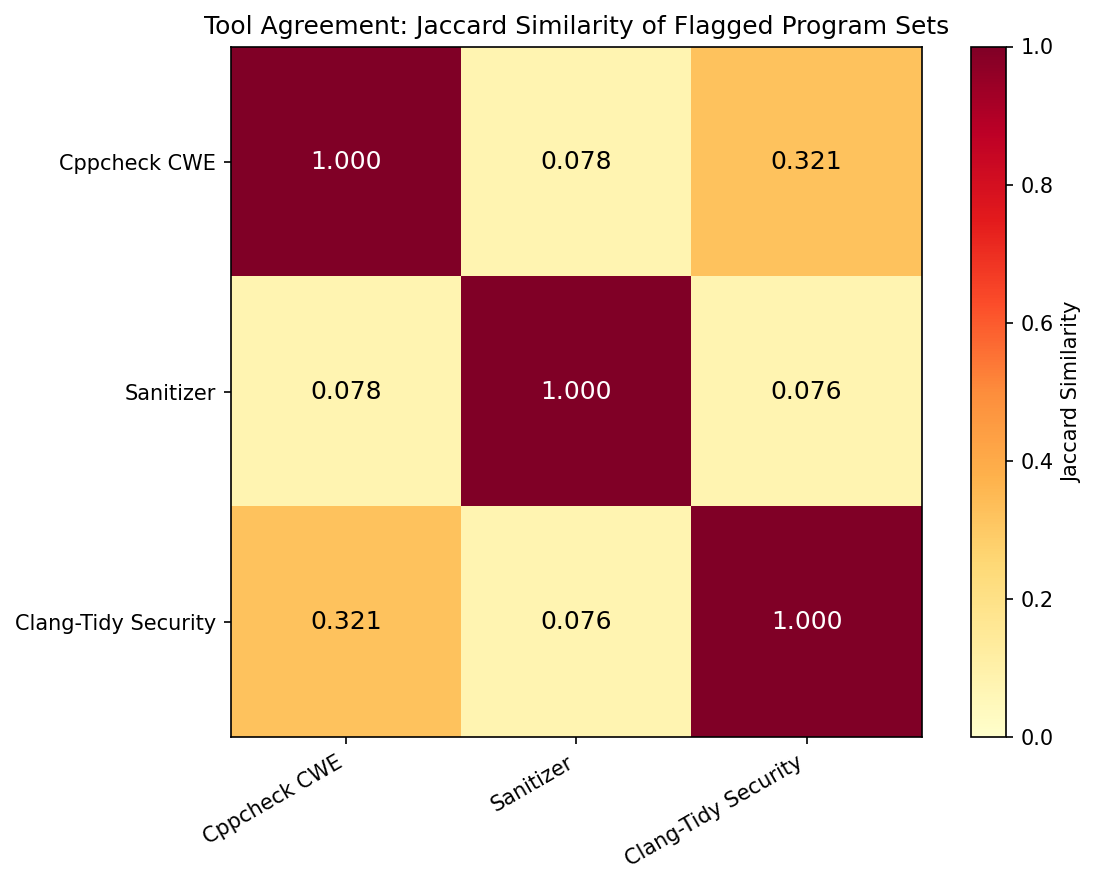

In [46]:
# Figure: Heatmap — tool detection overlap rates
fig, ax = plt.subplots(figsize=(8, 6))

# Compute pairwise overlap on full dataset (tier1)
tools = ['Cppcheck CWE', 'Sanitizer', 'Clang-Tidy Security']
# Add clang security flag to tier1
tier1_full = tier1.merge(master[['sample_id', 'clang_bugprone', 'clang_analyzer']], on='sample_id', how='left')
tier1_full['clang_sec_flag'] = (tier1_full['clang_bugprone'].fillna(0) + tier1_full['clang_analyzer'].fillna(0)) > 0

flags = {
    'Cppcheck CWE': tier1_full['cpp_flag'],
    'Sanitizer': tier1_full['san_flag'],
    'Clang-Tidy Security': tier1_full['clang_sec_flag'],
}

# Jaccard similarity matrix
n = len(tools)
jaccard_matrix = np.zeros((n, n))
for i, t1 in enumerate(tools):
    for j, t2 in enumerate(tools):
        s1 = set(tier1_full[flags[t1]].index)
        s2 = set(tier1_full[flags[t2]].index)
        if len(s1 | s2) > 0:
            jaccard_matrix[i, j] = len(s1 & s2) / len(s1 | s2)
        else:
            jaccard_matrix[i, j] = 0

im = ax.imshow(jaccard_matrix, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(tools, rotation=30, ha='right')
ax.set_yticklabels(tools)

for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{jaccard_matrix[i,j]:.3f}', ha='center', va='center', fontsize=12,
                color='white' if jaccard_matrix[i,j] > 0.5 else 'black')

plt.colorbar(im, label='Jaccard Similarity')
ax.set_title('Tool Agreement: Jaccard Similarity of Flagged Program Sets')
plt.tight_layout()
plt.savefig(f'{FIGURES}/cross_tool_jaccard_heatmap.pdf', bbox_inches='tight')
plt.savefig(f'{FIGURES}/cross_tool_jaccard_heatmap.png', bbox_inches='tight')
plt.show()

In [47]:
# Paper-ready summary: Verification tool comparison table
summary_rows = []
for model in ['gemma', 'llama', 'qwen', 'human']:
    m_master = master[master['model'] == model]
    m_san = san_summary[san_summary['model'] == model]
    m_esbmc = esbmc_summary[esbmc_summary['model'] == model]
    
    n_total = len(m_master)
    
    # Static: cppcheck CWE
    cpp_flagged = m_master['cppcheck_has_cwe'].sum()
    
    # Static: clang-tidy security (bugprone + analyzer)
    clang_sec = ((m_master['clang_bugprone'].fillna(0) + m_master['clang_analyzer'].fillna(0)) > 0).sum()
    
    # Dynamic: sanitizer triggered
    san_compiled = m_san['compiled'].sum()
    san_triggered = m_san['any_sanitizer_triggered'].sum()
    
    # Formal: ESBMC
    esbmc_analyzable = len(m_esbmc[m_esbmc['verdict'].isin(['SUCCESS', 'FAILED'])])
    esbmc_failed = len(m_esbmc[m_esbmc['verdict'] == 'FAILED'])
    
    summary_rows.append({
        'Model': model.capitalize(),
        'N programs': n_total,
        'Cppcheck CWE': f'{int(cpp_flagged)} ({cpp_flagged/n_total:.1%})',
        'Clang-Tidy Security': f'{int(clang_sec)} ({clang_sec/n_total:.1%})',
        'Sanitizer Triggered': f'{int(san_triggered)} ({san_triggered/san_compiled:.1%} of compiled)',
        'ESBMC Failed': f'{int(esbmc_failed)} ({esbmc_failed/max(esbmc_analyzable,1):.1%} of analyzable)',
        'ESBMC Coverage': f'{esbmc_analyzable} ({esbmc_analyzable/n_total:.1%})',
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(f'{TABLES}/verification_tool_summary.csv', index=False)
print('Table: Verification Tool Summary (paper-ready)')
summary_df

Table: Verification Tool Summary (paper-ready)


,Model,N programs,Cppcheck CWE,Clang-Tidy Security,Sanitizer Triggered,ESBMC Failed,ESBMC Coverage
0,Gemma,2238,1021 (45.6%),620 (27.7%),173 (8.6% of compiled),234 (25.9% of analyzable),904 (40.4%)
1,Llama,2496,840 (33.7%),838 (33.6%),217 (9.6% of compiled),271 (36.7% of analyzable),739 (29.6%)
2,Qwen,2489,908 (36.5%),740 (29.7%),224 (9.8% of compiled),135 (29.5% of analyzable),457 (18.4%)
3,Human,1695,765 (45.1%),1004 (59.2%),43 (2.6% of compiled),21 (18.8% of analyzable),112 (6.6%)


In [48]:
import glob

# List all Q-prefixed outputs
tables = sorted(glob.glob(f'{TABLES}/q*'))
figures = sorted(glob.glob(f'{FIGURES}/q*'))

print('=== Generated Tables ===')
for t in tables:
    print(f'  {os.path.basename(t)}')

print(f'\n=== Generated Figures ===')
for f in figures:
    print(f'  {os.path.basename(f)}')

=== Generated Tables ===
  q11_sensitivity_analysis.csv
  q11_tool_agreement.csv
  q12_tpr_warning_correlation_by_model.csv
  q12_tpr_warning_correlation_overall.csv
  q12_warnings_by_pass_status.csv
  q2_pipeline_attrition.csv
  q3_gen_comparison.csv
  q4_extraction_exclusion.csv
  q5_cwe_by_model_with_severity.csv
  q5_severity_aggregation.csv
  q5_top10_cwe_with_severity.csv
  q8_paired_by_model.csv
  q8_paired_comparison.csv
  q9_jaccard_warning_stability.csv
  qwen_mean_pass_rate_by_tag_and_gen.csv
  qwen_mean_pass_rate_by_tag_and_gen_pivot.csv
  qwen_mean_pass_rate_by_tags_and_gen.csv
  qwen_mean_pass_rate_by_tags_and_gen_pivot.csv
  qwen_mean_pass_rate_gen_1.csv
  qwen_mean_pass_rate_gen_2.csv
  qwen_mean_pass_rate_gen_3.csv
  qwen_pass_pct_by_tag_gen.csv

=== Generated Figures ===
  q11_sensitivity_analysis.pdf
  q11_sensitivity_analysis.png
  q12_tpr_vs_clang.pdf
  q12_tpr_vs_clang.png
  q12_warnings_by_status_violin.pdf
  q12_warnings_by_status_violin.png
  q2_pipeline_attrit